# Modelo XGBoost — Ejercicio Ex1 (extension/elevacion de hombro)

**PhysioVision · Diplomado Modulo 5 · notebook 1 de 2: entrenamiento**

Este notebook construye, evalua y **resguarda en disco** el clasificador XGBoost que
consume `src/classifier.py`, partiendo de los 26 videos de `data/videos/Ex1`. Termina
en la exportacion de los artefactos; no ejecuta la app.

El consumo de esos artefactos —inferencia sobre un video nuevo, redaccion con Gemini,
voz y la interfaz Gradio— esta en el segundo notebook:
[`consumo_modelo_gradio_ex1.ipynb`](consumo_modelo_gradio_ex1.ipynb).

Se ejecuta igual en local y en **Google Colab**: la seccion 0 se encarga de
traer el codigo, instalar lo que falte y avisar de que datos hay. Sin los
videos originales —que son datos de salud y no se publican— el notebook se
ejecuta entero igualmente, saltando lo que no puede calcular.

Pipeline completo:

| # | Seccion | Salida |
|---|---|---|
| 0 | **Entorno y reproducibilidad** | codigo, dependencias y datos disponibles |
| 1 | Configuracion | semillas, rutas, modelo `.task` |
| 2 | Inventario de videos | `df_videos` |
| 3 | Extraccion de landmarks (MediaPipe Pose) | `data/landmarks/Ex1/*.csv` |
| 4 | Control de calidad | tabla QC + mosaico de verificacion |
| 5 | Series angulares y segmentacion | `df_reps` (1 fila = 1 repeticion) |
| 6 | EDA | graficos y diagnostico de varianza |
| 7 | Feature engineering | `data/datasets/ex1_repeticiones.csv` |
| 8 | Etiquetado | `data/datasets/ex1_etiquetas.csv` |
| 9 | Particion y baselines | tabla comparativa |
| 10 | Hiperparametrizacion | mejores hiperparametros |
| 11 | Entrenamiento, evaluacion LOSO y **comparacion con Random Forest** | metricas out-of-fold + IC + tabla train/test |
| 12 | Resultados e interpretabilidad | matriz de confusion, calibracion, SHAP |
| 13 | **Exportacion y resguardo** | `models/xgboost_model.json`, `feature_contract.json`, `umbrales_ex1.json`, `model_card.md` |
| 14 | Conclusiones y recomendaciones | hallazgos, decisiones y mejoras |

> **Descargo clinico.** Este modelo es material academico. No constituye diagnostico
> ni sustituye el criterio de un profesional de la salud.

---
## 0. Entorno y reproducibilidad

Este notebook se ejecuta igual en local y en **Google Colab**. La celda 0.1 se
encarga de las tres cosas que cambian entre un sitio y otro: traer el código,
instalar lo que falte y averiguar qué datos hay disponibles.

### Qué datos hacen falta y cuáles se publican

| Qué | Dónde | ¿Viaja con el repositorio? |
|---|---|---|
| Código (`src/`) y artefactos (`models/`) | repositorio | **sí** |
| Vídeos de los 13 sujetos | `data/videos/Ex1/` | **no**: son datos de salud identificables |
| Landmarks y dataset derivado | `data/landmarks/`, `data/datasets/` | **no** por la misma razón |

**Sin los vídeos el notebook sigue funcionando**: las secciones que los
necesitan se saltan solas y avisan, y el análisis continúa desde el dataset ya
calculado si está disponible. Lo que no se hace nunca es fallar a mitad.

### Para ejecutarlo completo en Colab

Sube tu copia de `data/` a Google Drive y móntala antes de la celda 0.1:

```python
from google.colab import drive
drive.mount('/content/drive')
import os; os.environ['PHYSIOVISION_DATOS_EXTERNOS'] = '/content/drive/MyDrive/physiovision/data'
```

La celda 0.1 detecta esa variable y usa esos datos.

In [ ]:
# 0.1 Entorno: código, dependencias y datos disponibles.
#
# Idempotente: se puede reejecutar sin efectos. No usa magias de Jupyter (`%cd`,
# `!pip`) a propósito, para que el mismo código valga en Colab, en Jupyter local
# y ejecutado como script.
import os
import subprocess
import sys
from pathlib import Path

REPO = "https://github.com/daff-250900/phyisiovision.git"

#: Solo lo que Colab no trae ya. Las versiones son las del entorno donde se
#: validó el modelo (ver requirements.lock): mediapipe determina los landmarks y
#: xgboost el clasificador, así que no se dejan al azar.
PAQUETES = ["mediapipe==0.10.35", "xgboost==3.2.0"]

EN_COLAB = "google.colab" in sys.modules or bool(os.environ.get("COLAB_RELEASE_TAG"))

if EN_COLAB:
    destino = Path("/content/phyisiovision")
    if not destino.exists():
        print("Clonando el repositorio...")
        subprocess.run(["git", "clone", "--depth", "1", "--quiet", REPO, str(destino)],
                       check=True)
    os.chdir(destino / "entrenamiento")

    faltan = []
    for paquete in PAQUETES:
        nombre = paquete.split("==")[0]
        try:
            __import__(nombre)
        except ImportError:
            faltan.append(paquete)
    if faltan:
        print(f"Instalando {', '.join(faltan)} (un par de minutos)...")
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *faltan],
                       check=True)

# El notebook vive en entrenamiento/; la raiz del proyecto es el directorio padre.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "entrenamiento" else NB_DIR
if not (BASE_DIR / "src").exists() and (BASE_DIR.parent / "src").exists():
    BASE_DIR = BASE_DIR.parent
sys.path.insert(0, str(BASE_DIR))

# Los datos pueden estar en el repositorio o montados aparte (Drive, un disco).
DATOS_DIR = Path(os.environ.get("PHYSIOVISION_DATOS_EXTERNOS", BASE_DIR / "data"))

VIDEO_DIR = DATOS_DIR / "videos" / "Ex1"
LANDMARK_DIR = DATOS_DIR / "landmarks" / "Ex1"
DATASET_DIR = DATOS_DIR / "datasets"
MODEL_DIR = BASE_DIR / "models"

HAY_VIDEOS = VIDEO_DIR.exists() and any(VIDEO_DIR.glob("*.mp4"))
HAY_LANDMARKS = LANDMARK_DIR.exists() and any(LANDMARK_DIR.glob("*.csv"))
HAY_DATASET = (DATASET_DIR / "ex1_repeticiones.csv").exists()
HAY_MODELO = (MODEL_DIR / "xgboost_model.json").exists()

print(f"Entorno   : {'Google Colab' if EN_COLAB else 'local'}")
print(f"Proyecto  : {BASE_DIR}")
print(f"Datos     : {DATOS_DIR}\n")
print("Disponible                          Secciones que habilita")
print("-" * 70)
for etiqueta, hay, secciones in [
    ("videos originales", HAY_VIDEOS, "2 a 5 (extraccion y segmentacion)"),
    ("landmarks ya extraidos", HAY_LANDMARKS, "3 a 5 sin reprocesar video"),
    ("dataset de repeticiones", HAY_DATASET, "6 a 14 (EDA, etiquetado, modelo)"),
    ("modelo entrenado", HAY_MODELO, "13 (verificacion de la exportacion)"),
]:
    print(f"  {'si' if hay else 'NO':3s}  {etiqueta:30s} {secciones}")

if not (HAY_VIDEOS or HAY_DATASET):
    print("\nSin videos ni dataset: el notebook se ejecutara entero mostrando el")
    print("metodo, y saltara los calculos que necesitan datos. Para ejecutarlo")
    print("completo, monta tu copia de data/ como explica la seccion 0.")

### 0.2 Hallazgos del entorno que condicionan este notebook

Verificados sobre este `.venv` y sobre los videos reales antes de escribir el codigo:

1. **`mediapipe 0.10.35` no incluye la API legacy `mp.solutions`.** Solo expone
   `mediapipe.tasks`. Por eso aqui se usa `PoseLandmarker` (API Tasks) y no
   `mp.solutions.pose` como hace `src/pose_detector.py:12`, que **esta roto con este
   entorno**. La API Tasks requiere descargar un archivo `.task` (celda 1.2).

2. **Camera17 es vista frontal y Camera18 vista lateral.** En Camera18 la visibilidad
   del codo y la muneca del lado ocluido cae a ~0.0. No son dos copias del mismo dato:
   cada vista mide cosas distintas y eso se modela con la variable `vista`.

3. **El brazo activo cambia entre sujetos.** Medido en 3 sujetos: PM_000 y PM_012 mueven
   ambos brazos, PM_101 solo el derecho (rango izquierdo 22 grados = practicamente
   estatico). Fijar el lado izquierdo como hace `src/feature_engineering.py:47` produciria
   variables sin senal en varios sujetos. Aqui el lado activo **se detecta por sujeto**.

4. **Los angulos se calculan sobre `pose_world_landmarks`** (metros, centrados en la
   cadera) y no sobre las coordenadas normalizadas de imagen. Esto elimina de raiz el
   sesgo de relacion de aspecto descrito en `PLAN.md` Fase 1.1 (un angulo real de 90
   grados se mide como ~62 grados con `x`,`y` normalizados independientes) y hace
   comparables Camera17 (1920x1080) y Camera18 (1080x1920).

5. **Las dos camaras estan sincronizadas** (identico `frame_count` por sujeto), asi que la
   repeticion *k* del sujeto *i* es el mismo gesto en ambas vistas. Se etiqueta una vez y
   se aplica a las dos.

---
## 1. Configuracion

Semillas, rutas y parametros del pipeline. Todo lo que cambia entre entornos
—donde esta el codigo, que datos hay— se resolvio en la seccion 0; aqui solo
queda lo propio del ejercicio.


### 1.1 Dependencias

Obligatorias (ya presentes en el `.venv`): `mediapipe`, `opencv-python-headless`,
`numpy`, `pandas`, `scipy`, `scikit-learn`, `xgboost`, `matplotlib`, `tqdm`.

Opcionales — el notebook funciona sin ellas con alternativas equivalentes:

| Paquete | Si falta |
|---|---|
| `optuna` | se usa `RandomizedSearchCV` |
| `shap` | se usa importancia por permutacion |
| `ipywidgets` | el etiquetado se hace editando un CSV |
| `imageio` | los clips de revision se guardan como mosaicos PNG |

In [2]:
# Descomenta para instalar las dependencias opcionales:
# %pip install optuna shap ipywidgets imageio seaborn

In [3]:
from __future__ import annotations

import json
import math
import os
import sys
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---- Reproducibilidad -------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# ---- Rutas ------------------------------------------------------------------
# Las rutas y la deteccion de entorno viven en la seccion 0.1, que ya se ha
# ejecutado. Aqui solo se anade lo especifico del ejercicio.
EJERCICIO = "Ex1"
FIG_DIR = BASE_DIR / "entrenamiento" / "figuras"
MP_MODEL = MODEL_DIR / "mediapipe" / "pose_landmarker_heavy.task"

for d in (LANDMARK_DIR, DATASET_DIR, MODEL_DIR / "mediapipe", FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Parametros del pipeline ------------------------------------------------
FPS_NOMINAL = 30.0
MAX_LADO = 960          # reescalado del lado mayor antes de inferir
MIN_VISIBILIDAD = 0.5   # visibilidad minima para considerar valido un landmark
SUAVIZADO_SEG = 0.40    # ventana Savitzky-Golay en segundos
MIN_DUR_REP = 1.0       # duracion minima de una repeticion, en segundos
MIN_AMPLITUD_REP = 20.0 # amplitud angular minima para contar como repeticion (grados)

# SUBSET: None = todos los videos. Una lista de sujetos acota la corrida (util para probar).
SUBSET = None
if os.environ.get("PV_SUBSET"):
    SUBSET = os.environ["PV_SUBSET"].split(",")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.facecolor": "white"})
PALETA = {"rango_insuficiente": "#D97757", "correcto": "#4F9D69", "compensacion_tronco": "#6B7FD7"}

print(f"Ejercicio : {EJERCICIO}")
print(f"Videos    : {len(list(VIDEO_DIR.glob('*.mp4'))) if HAY_VIDEOS else 0} archivos")
print(f"Subset    : {SUBSET or 'todos'}")

Proyecto : /Users/dafnezepedagonzalez/Documents/Diplomado/Modulo5/physiovision_gradio
Videos   : /Users/dafnezepedagonzalez/Documents/Diplomado/Modulo5/physiovision_gradio/data/videos/Ex1  (26 archivos)
Subset   : todos


### 1.2 Modelo de MediaPipe Pose (API Tasks)

`PoseLandmarker` necesita un archivo `.task`. Se descarga una sola vez a
`models/mediapipe/`. Se usa la variante **heavy** porque aqui prima la precision:
es un proceso por lotes, no tiempo real. (La app puede seguir con `lite` o `full`.)

In [4]:
import mediapipe as mp

from src.pose_detector import descargar_modelo

# La descarga y la gestion de variantes viven en src/pose_detector.py, que es
# tambien el que usa la app. Aqui se pide "heavy" porque este es un proceso por
# lotes y prima la precision; la app usa "full" o "lite" por rendimiento.
MP_MODEL = descargar_modelo("heavy")

print(f"Modelo MediaPipe: {MP_MODEL.name}  ({MP_MODEL.stat().st_size/1e6:.1f} MB)")
print(f"mediapipe {mp.__version__} — API Tasks")

Modelo MediaPipe: pose_landmarker_heavy.task  (30.7 MB)
mediapipe 0.10.35 — API Tasks


---
## 2. Inventario de videos

Los nombres siguen el patron `PM_<sujeto>-Camera<id>-30fps[-transposed].mp4`.
El **sujeto** es la unidad de agrupacion para todas las particiones posteriores:
las dos vistas de una misma persona son casi duplicados y nunca pueden quedar
repartidas entre entrenamiento y prueba.

In [5]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    import re

    PATRON = re.compile(r"^(?P<sujeto>PM_\d+)-(?P<camara>Camera\d+)")


    def inventariar(video_dir: Path, subset=None) -> pd.DataFrame:
        filas = []
        for path in sorted(video_dir.glob("*.mp4")):
            m = PATRON.match(path.name)
            if not m:
                continue
            if subset and m.group("sujeto") not in subset:
                continue
            cap = cv2.VideoCapture(str(path))
            n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS) or FPS_NOMINAL
            w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            cap.release()
            filas.append({
                "video_id": path.stem,
                "sujeto": m.group("sujeto"),
                "camara": m.group("camara"),
                "vista": "frontal" if m.group("camara") == "Camera17" else "lateral",
                "path": str(path),
                "n_frames": n_frames,
                "fps": round(fps, 2),
                "duracion_s": round(n_frames / max(fps, 1), 1),
                "ancho": w, "alto": h,
                "orientacion": "apaisado" if w >= h else "vertical",
            })
        return pd.DataFrame(filas)


    df_videos = inventariar(VIDEO_DIR, SUBSET)

    print(f"{len(df_videos)} videos | {df_videos.sujeto.nunique()} sujetos | "
          f"{df_videos.n_frames.sum():,} frames | {df_videos.duracion_s.sum()/60:.1f} min")
    display(df_videos.groupby(["camara", "vista", "orientacion"])
            .agg(videos=("video_id", "count"), frames=("n_frames", "sum"),
                 dur_min=("duracion_s", lambda s: round(s.sum()/60, 1))))
    df_videos.head(4)

26 videos | 13 sujetos | 73,540 frames | 40.9 min


,,,videos,frames,dur_min
camara,vista,orientacion,,,
Camera17,frontal,apaisado,13,36770,20.4
Camera18,lateral,vertical,13,36770,20.4


,video_id,sujeto,camara,vista,path,n_frames,fps,duracion_s,ancho,alto,orientacion
0,PM_000-Camera17-30fps,PM_000,Camera17,frontal,/Users/dafnezepedagonzalez/Documents/Diplomado...,1304,30.0,43.5,1920,1080,apaisado
1,PM_000-Camera18-30fps-transposed,PM_000,Camera18,lateral,/Users/dafnezepedagonzalez/Documents/Diplomado...,1304,30.0,43.5,1080,1920,vertical
2,PM_001-Camera17-30fps,PM_001,Camera17,frontal,/Users/dafnezepedagonzalez/Documents/Diplomado...,3016,30.0,100.5,1920,1080,apaisado
3,PM_001-Camera18-30fps-transposed,PM_001,Camera18,lateral,/Users/dafnezepedagonzalez/Documents/Diplomado...,3016,30.0,100.5,1080,1920,vertical


In [6]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # Verificacion de sincronia entre camaras: mismo sujeto debe tener el mismo n_frames.
    sync = (df_videos.pivot_table(index="sujeto", columns="camara", values="n_frames", aggfunc="first"))
    if sync.shape[1] == 2:
        sync["sincronizado"] = sync.iloc[:, 0] == sync.iloc[:, 1]
        n_ok = int(sync["sincronizado"].sum())
        print(f"Sujetos con camaras sincronizadas: {n_ok}/{len(sync)}")
        if n_ok < len(sync):
            print("AVISO: sin sincronia no se puede propagar la etiqueta entre vistas en esos sujetos.")
        display(sync)

Sujetos con camaras sincronizadas: 13/13


camara,Camera17,Camera18,sincronizado
sujeto,,,
PM_000,1304,1304,True
PM_001,3016,3016,True
PM_002,1996,1996,True
PM_012,2403,2403,True
PM_016,2043,2043,True
PM_023,1710,1710,True
PM_024,2104,2104,True
PM_032,2951,2951,True
PM_039,3803,3803,True


---
## 3. Extraccion de landmarks con MediaPipe Pose

Se guarda **un CSV por video** en `data/landmarks/Ex1/`. Cada fila es un frame.

Columnas por cada uno de los 13 landmarks relevantes:

- `<nombre>_x, _y, _z, _v` — coordenadas normalizadas a la imagen + visibilidad.
- `<nombre>_wx, _wy, _wz` — **world landmarks** en metros, centrados en la cadera.
  Son los que se usan para todos los angulos (ver hallazgo 4 de la seccion 0).

El proceso es **idempotente**: si el CSV de un video ya existe, se salta. Asi el
notebook se puede reejecutar de arriba abajo sin volver a pagar los ~20 minutos de
inferencia.

In [7]:
# El esquema de landmarks vive en src/features_ex1.py, que es tambien el que usa
# la app. Importarlo en vez de redefinirlo evita que las dos rutas diverjan.
from src.features_ex1 import COLUMNAS, LANDMARKS, NOMBRES

print(f"{len(LANDMARKS)} landmarks -> {len(COLUMNAS)} columnas por CSV")

13 landmarks -> 93 columnas por CSV


In [8]:
from src.pose_detector import extraer_landmarks

# Misma funcion que usa la app: modo VIDEO (sincrono, procesa todos los frames),
# coordenadas normalizadas + world, y el esquema de columnas de features_ex1.
print("extraccion importada de src/pose_detector.py")

extraccion importada de src/pose_detector.py


In [9]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    def extraer_todos(df_videos: pd.DataFrame, forzar: bool = False) -> None:
        pendientes = []
        for fila in df_videos.itertuples():
            destino = LANDMARK_DIR / f"{fila.video_id}.csv"
            if destino.exists() and not forzar:
                continue
            pendientes.append((fila, destino))

        if not pendientes:
            print("Todos los CSV de landmarks ya existen. Nada que extraer.")
            return

        print(f"Extrayendo {len(pendientes)} video(s)...")
        t0 = time.time()
        for fila, destino in tqdm(pendientes, desc="videos"):
            df = extraer_landmarks(fila.path)
            df.round(5).to_csv(destino, index=False)
            detectados = df[f"{NOMBRES[0]}_x"].notna().mean()
            tqdm.write(f"  {fila.video_id:42s} {len(df):5d} frames  deteccion {detectados:5.1%}")
        print(f"Listo en {(time.time()-t0)/60:.1f} min")


    extraer_todos(df_videos)

    csvs = sorted(LANDMARK_DIR.glob("*.csv"))
    print(f"\n{len(csvs)} CSV en {LANDMARK_DIR.relative_to(BASE_DIR)} "
          f"({sum(p.stat().st_size for p in csvs)/1e6:.0f} MB)")

Todos los CSV de landmarks ya existen. Nada que extraer.

26 CSV en data/landmarks/Ex1 (56 MB)


---
## 4. Control de calidad de la extraccion

Sin este paso se entrena sobre videos donde MediaPipe no vio nada, o donde vio a la
persona acostada. Tres controles:

1. **Tasa de deteccion y visibilidad** por video.
2. **Verificacion de orientacion**: un frame anotado por video en un mosaico. Es un
   fallo silencioso — con la persona de lado MediaPipe devuelve landmarks plausibles
   pero incorrectos, sin lanzar ningun error.
3. **Continuidad**: saltos bruscos de la cadera delatan cambios de sujeto o
   detecciones erraticas.

In [10]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    def cargar_landmarks(video_id: str) -> pd.DataFrame:
        return pd.read_csv(LANDMARK_DIR / f"{video_id}.csv")


    ARTICULACIONES = ["left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
                      "left_wrist", "right_wrist", "left_hip", "right_hip"]

    qc = []
    landmarks_cache = {}
    for fila in tqdm(list(df_videos.itertuples()), desc="QC"):
        df = cargar_landmarks(fila.video_id)
        landmarks_cache[fila.video_id] = df
        detectado = df["nose_x"].notna()
        vis = df[[f"{n}_v" for n in ARTICULACIONES]]
        # Salto de cadera entre frames consecutivos (en unidades normalizadas).
        cad = df[["left_hip_x", "left_hip_y"]].to_numpy()
        salto = np.linalg.norm(np.diff(cad, axis=0), axis=1)
        qc.append({
            "video_id": fila.video_id, "sujeto": fila.sujeto, "vista": fila.vista,
            "n_frames": len(df),
            "tasa_deteccion": detectado.mean(),
            "vis_media": float(vis.mean().mean()),
            "vis_min_articulacion": float(vis.mean().min()),
            "articulacion_peor": vis.mean().idxmin().replace("_v", ""),
            "saltos_bruscos": int((salto > 0.10).sum()),
        })

    df_qc = pd.DataFrame(qc)
    df_qc["estado"] = np.where(
        (df_qc.tasa_deteccion >= 0.90) & (df_qc.vis_media >= 0.60), "OK",
        np.where(df_qc.tasa_deteccion >= 0.70, "REVISAR", "DESCARTAR"))

    print(df_qc.estado.value_counts().to_string())
    display(df_qc.sort_values("tasa_deteccion")
            .style.format({"tasa_deteccion": "{:.1%}", "vis_media": "{:.2f}",
                           "vis_min_articulacion": "{:.2f}"})
            .background_gradient(subset=["tasa_deteccion", "vis_media"], cmap="RdYlGn"))

QC:   0%|          | 0/26 [00:00<?, ?it/s]

estado
OK    26


,video_id,sujeto,vista,n_frames,tasa_deteccion,vis_media,vis_min_articulacion,articulacion_peor,saltos_bruscos,estado
6,PM_012-Camera17-30fps,PM_012,frontal,2403,99.9%,0.99,0.98,right_elbow,0,OK
0,PM_000-Camera17-30fps,PM_000,frontal,1304,100.0%,0.99,0.98,left_elbow,0,OK
23,PM_114-Camera18-30fps-transposed,PM_114,lateral,5168,100.0%,0.81,0.26,right_elbow,0,OK
22,PM_114-Camera17-30fps,PM_114,frontal,5168,100.0%,0.96,0.77,left_elbow,0,OK
21,PM_109-Camera18-30fps-transposed,PM_109,lateral,5226,100.0%,0.84,0.34,right_elbow,0,OK
20,PM_109-Camera17-30fps,PM_109,frontal,5226,100.0%,0.95,0.78,left_elbow,0,OK
19,PM_101-Camera18-30fps-transposed,PM_101,lateral,1307,100.0%,0.96,0.80,right_elbow,0,OK
18,PM_101-Camera17-30fps,PM_101,frontal,1307,100.0%,0.87,0.33,left_elbow,0,OK
17,PM_039-Camera18-30fps-transposed,PM_039,lateral,3803,100.0%,0.84,0.36,right_elbow,0,OK
16,PM_039-Camera17-30fps,PM_039,frontal,3803,100.0%,0.96,0.80,left_elbow,0,OK


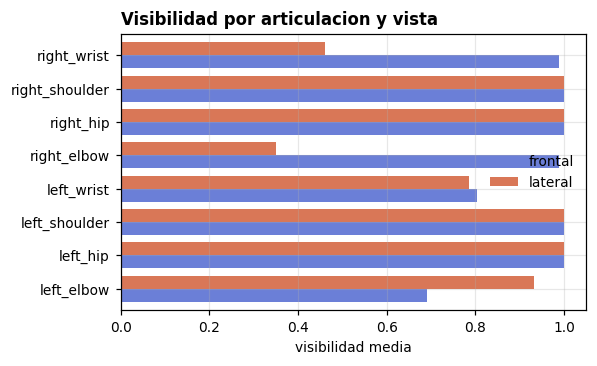

vista,frontal,lateral
articulacion,,
left_elbow,0.69,0.93
left_hip,1.00,1.00
left_shoulder,1.00,1.00
left_wrist,0.80,0.78
right_elbow,0.99,0.35
right_hip,1.00,1.00
right_shoulder,1.00,1.00
right_wrist,0.99,0.46


In [11]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # Visibilidad media por articulacion y vista: confirma que la lateral ocluye un lado.
    vis_vista = []
    for fila in df_videos.itertuples():
        df = landmarks_cache[fila.video_id]
        for art in ARTICULACIONES:
            vis_vista.append({"vista": fila.vista, "articulacion": art,
                              "visibilidad": df[f"{art}_v"].mean()})
    piv = (pd.DataFrame(vis_vista).pivot_table(index="articulacion", columns="vista",
                                               values="visibilidad", aggfunc="mean"))
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    piv.plot(kind="barh", ax=ax, color=["#6B7FD7", "#D97757"], width=0.78)
    ax.set_xlabel("visibilidad media"); ax.set_ylabel("")
    ax.set_title("Visibilidad por articulacion y vista", loc="left", fontweight="bold")
    ax.legend(title="", frameon=False); ax.set_xlim(0, 1.05)
    plt.tight_layout(); plt.show()
    display(piv.round(2))

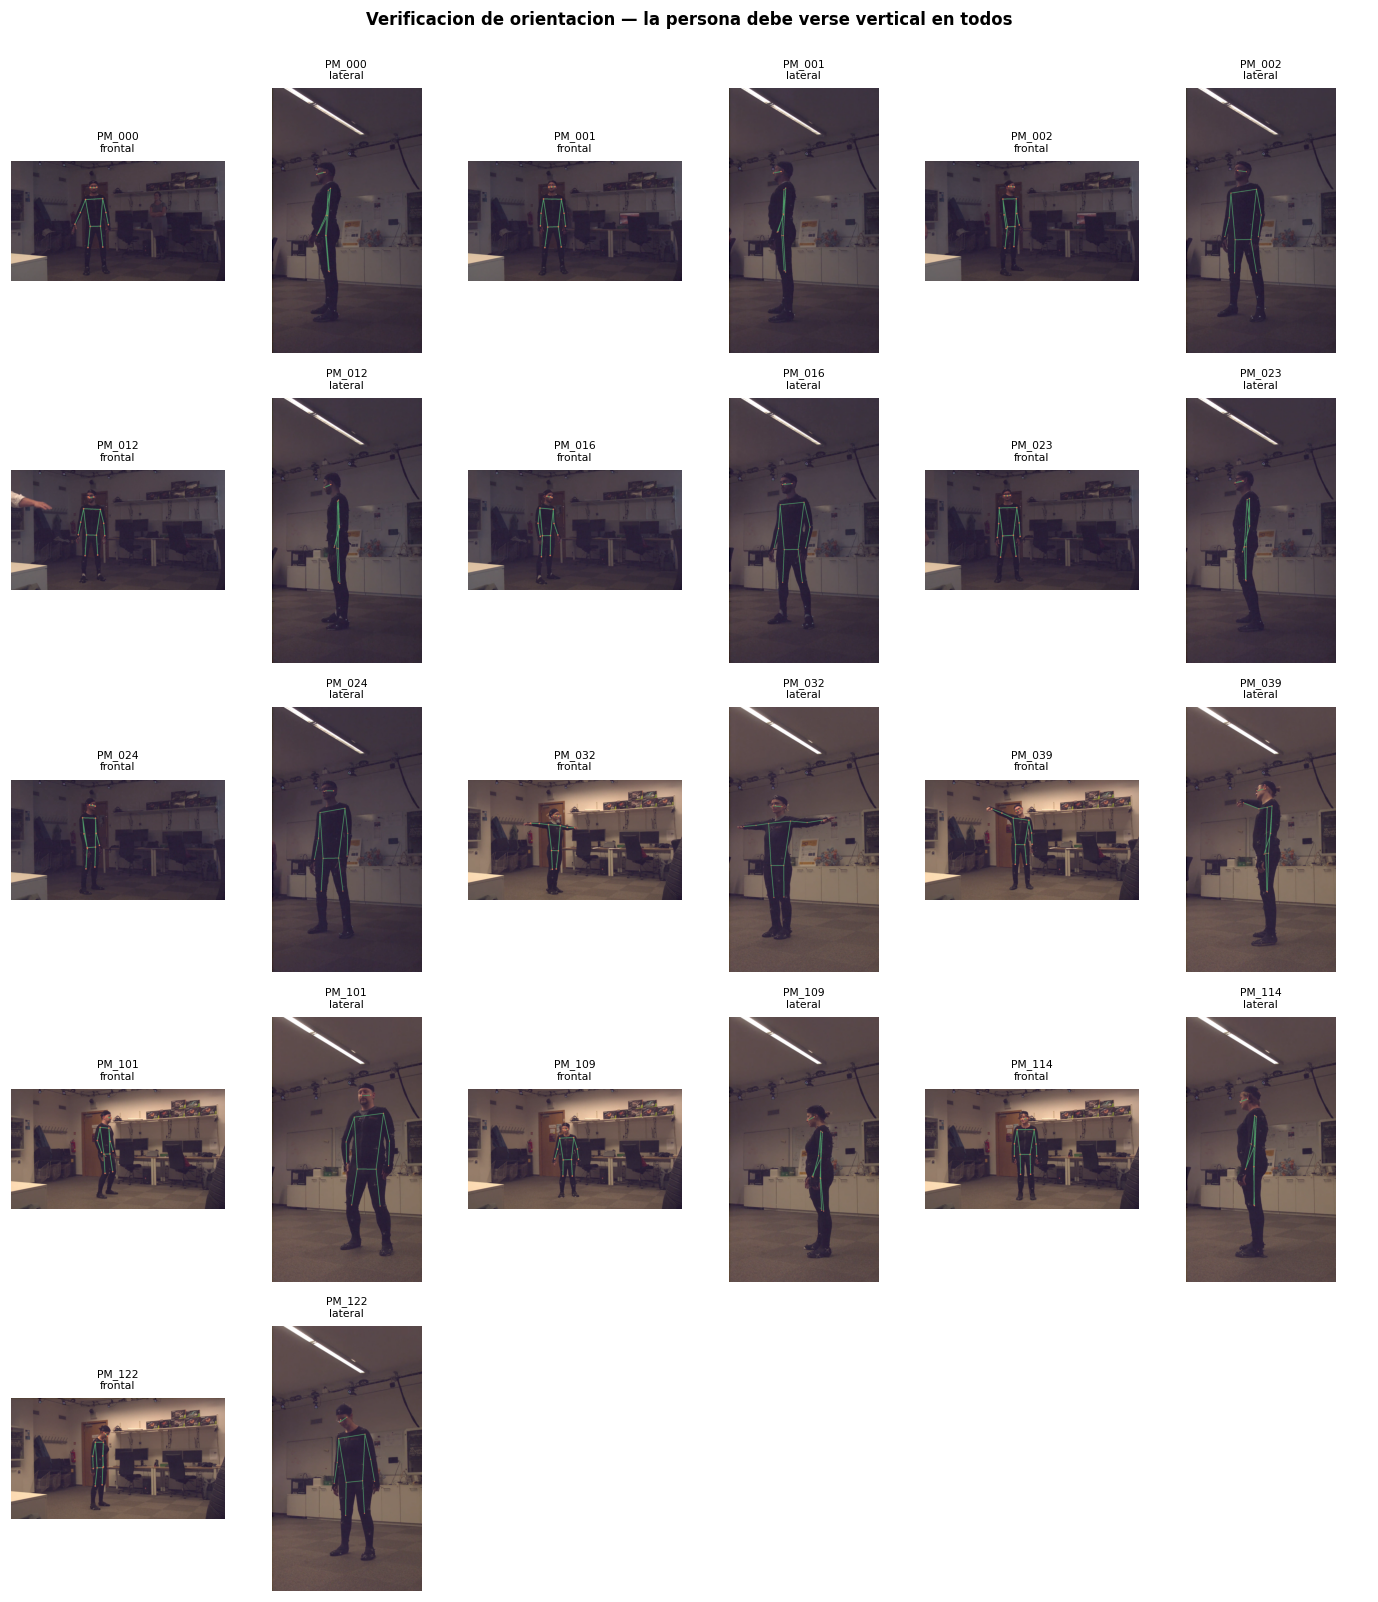

In [12]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # Mosaico de verificacion de orientacion: un frame por video con el esqueleto dibujado.
    CONEXIONES = [("left_shoulder", "right_shoulder"), ("left_shoulder", "left_elbow"),
                  ("left_elbow", "left_wrist"), ("right_shoulder", "right_elbow"),
                  ("right_elbow", "right_wrist"), ("left_shoulder", "left_hip"),
                  ("right_shoulder", "right_hip"), ("left_hip", "right_hip"),
                  ("left_hip", "left_knee"), ("right_hip", "right_knee"),
                  ("nose", "left_ear"), ("nose", "right_ear")]


    def frame_anotado(fila, n_frame=None):
        df = landmarks_cache[fila.video_id]
        validos = df.index[df["nose_x"].notna()]
        if len(validos) == 0:
            return None
        n_frame = n_frame if n_frame is not None else validos[len(validos) // 2]
        cap = cv2.VideoCapture(fila.path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(n_frame))
        ok, img = cap.read()
        cap.release()
        if not ok:
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        fl = df.loc[n_frame]
        pt = lambda n: (int(fl[f"{n}_x"] * w), int(fl[f"{n}_y"] * h))
        for a, b in CONEXIONES:
            cv2.line(img, pt(a), pt(b), (79, 157, 105), max(2, w // 350))
        for n in NOMBRES:
            cv2.circle(img, pt(n), max(3, w // 260), (217, 119, 87), -1)
        return img


    muestra = df_videos.itertuples()
    n_col = 6
    fila_lista = list(muestra)
    n_fil = int(np.ceil(len(fila_lista) / n_col))
    fig, axes = plt.subplots(n_fil, n_col, figsize=(2.1 * n_col, 2.9 * n_fil))
    for ax, fila in zip(np.array(axes).ravel(), fila_lista):
        img = frame_anotado(fila)
        if img is not None:
            ax.imshow(img)
        ax.set_title(f"{fila.sujeto}\n{fila.vista}", fontsize=7)
        ax.axis("off")
    for ax in np.array(axes).ravel()[len(fila_lista):]:
        ax.axis("off")
    fig.suptitle("Verificacion de orientacion — la persona debe verse vertical en todos",
                 fontweight="bold", y=1.0)
    plt.tight_layout(); plt.savefig(FIG_DIR / "qc_orientacion.png", bbox_inches="tight"); plt.show()

In [13]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    VIDEOS_VALIDOS = df_qc.loc[df_qc.estado != "DESCARTAR", "video_id"].tolist()
    descartados = df_qc.loc[df_qc.estado == "DESCARTAR"]
    if len(descartados):
        print("Videos descartados por baja tasa de deteccion:")
        display(descartados[["video_id", "tasa_deteccion", "vis_media"]])
    else:
        print("Ningun video descartado.")
    print(f"{len(VIDEOS_VALIDOS)}/{len(df_videos)} videos continuan al analisis.")

Ningun video descartado.
26/26 videos continuan al analisis.


---
## 5. Series angulares y segmentacion en repeticiones

**La unidad de observacion es la repeticion, no el video.** 26 videos son 26 muestras:
imposible entrenar nada. Segmentando por ciclos se pasa a varios cientos de muestras.

### 5.1 Geometria sobre world landmarks

Todos los angulos se calculan en 3D metrico. En el sistema de world landmarks de
MediaPipe el eje `y` **crece hacia abajo** (verificado: hombro `y = -0.44`,
cadera `y = 0.00`), asi que la vertical hacia arriba es `(0, -1, 0)`.

In [14]:
from src.features_ex1 import ARRIBA, angulo_3d, angulo_con_vertical, w

# ARRIBA = (0, -1, 0): en world landmarks el eje y crece hacia abajo.
print("geometria importada de src/features_ex1.py")

geometria importada de src/features_ex1.py


In [15]:
from src.features_ex1 import series_angulares

# Calcula abduccion de hombro, flexion de codo, inclinacion y lean del tronco,
# elevacion escapular y simetria, todo sobre coordenadas world.
print(series_angulares.__doc__.splitlines()[0])

Convierte un DataFrame de landmarks en las series angulares de un lado.


### 5.2 Deteccion del lado activo

Verificado sobre los datos: el brazo que trabaja **cambia entre sujetos**. Se elige
por sujeto el lado con mayor recorrido angular, medido en la **vista frontal**, que es
donde ambos brazos son visibles. El resultado se propaga a la vista lateral del mismo
sujeto: es el mismo gesto grabado desde otro angulo.

In [16]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    from src.features_ex1 import detectar_lado

    filas_lado = []
    for sujeto, grupo in df_videos[df_videos.video_id.isin(VIDEOS_VALIDOS)].groupby("sujeto"):
        # Preferir la vista frontal para decidir; si no hay, usar la que exista.
        ref = grupo[grupo.vista == "frontal"]
        ref = ref if len(ref) else grupo
        fila = ref.iloc[0]
        lado, r_izq, r_der = detectar_lado(landmarks_cache[fila.video_id])
        filas_lado.append({"sujeto": sujeto, "lado_activo": lado,
                           "rango_izq": round(r_izq, 1), "rango_der": round(r_der, 1),
                           "decidido_en": fila.vista})

    df_lado = pd.DataFrame(filas_lado)
    LADO_ACTIVO = dict(zip(df_lado.sujeto, df_lado.lado_activo))
    print(df_lado.lado_activo.value_counts().to_string())
    display(df_lado)

lado_activo
right    13


,sujeto,lado_activo,rango_izq,rango_der,decidido_en
0,PM_000,right,87.7,135.6,frontal
1,PM_001,right,37.4,111.3,frontal
2,PM_002,right,77.2,91.8,frontal
3,PM_012,right,38.5,118.0,frontal
4,PM_016,right,89.2,90.0,frontal
5,PM_023,right,75.1,124.7,frontal
6,PM_024,right,86.2,111.6,frontal
7,PM_032,right,84.1,117.0,frontal
8,PM_039,right,87.9,114.7,frontal
9,PM_101,right,15.6,101.0,frontal


### 5.3 Segmentacion en repeticiones

Sobre la senal de abduccion del lado activo:

1. Interpolar huecos cortos (menos de 5 frames) y descartar tramos largos sin pose.
2. Suavizado **Savitzky-Golay** (ventana ~0.4 s, orden 3). Preserva la amplitud de los
   picos, a diferencia de la media movil, que los aplana y sesgaria el ROM a la baja.
3. `find_peaks` con prominencia relativa al rango de la senal y separacion minima de
   1 s -> picos (maxima elevacion) y valles (posicion de reposo).
4. Cada repeticion = valle -> pico -> valle, filtrando amplitudes y duraciones anomalas.

La segmentacion se hace en la **vista frontal** y los indices de frame se reutilizan en
la lateral, aprovechando que las camaras estan sincronizadas.

In [17]:
from src.features_ex1 import prominencia_para, segmentar, suavizar

# suavizar(): Savitzky-Golay centrado, preserva la amplitud de los picos.
# segmentar(): valle -> pico -> valle con find_peaks. La version causal
# equivalente para camara en vivo esta en src/segmentador_online.py.
print("segmentacion importada de src/features_ex1.py")

segmentacion importada de src/features_ex1.py


In [18]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # Series angulares de cada video con su lado activo + segmentacion por sujeto.
    series_cache, segmentos = {}, {}

    for fila in df_videos[df_videos.video_id.isin(VIDEOS_VALIDOS)].itertuples():
        lado = LADO_ACTIVO.get(fila.sujeto, "right")
        s = series_angulares(landmarks_cache[fila.video_id], lado)
        s["abduccion_suave"] = suavizar(s["abduccion_hombro"].where(s.valido), fila.fps)
        series_cache[fila.video_id] = s

    # Un unico juego de repeticiones por sujeto, definido en la vista frontal.
    for sujeto, grupo in df_videos[df_videos.video_id.isin(VIDEOS_VALIDOS)].groupby("sujeto"):
        ref = grupo[grupo.vista == "frontal"]
        ref = ref if len(ref) else grupo
        fila = ref.iloc[0]
        segmentos[sujeto] = segmentar(series_cache[fila.video_id]["abduccion_suave"].to_numpy(),
                                      fila.fps)

    resumen_seg = pd.DataFrame([
        {"sujeto": s, "n_reps": len(r),
         "amplitud_media": round(np.mean([x["amplitud"] for x in r]), 1) if r else np.nan,
         "duracion_media_s": round(np.mean([x["duracion_s"] for x in r]), 1) if r else np.nan}
        for s, r in segmentos.items()])
    print(f"Total de repeticiones detectadas: {resumen_seg.n_reps.sum()} "
          f"en {len(resumen_seg)} sujetos")
    display(resumen_seg.sort_values("n_reps"))

Total de repeticiones detectadas: 167 en 13 sujetos


,sujeto,n_reps,amplitud_media,duracion_media_s
0,PM_000,4,129.7,7.7
1,PM_001,8,107.4,7.7
2,PM_002,8,84.0,7.3
3,PM_012,8,105.9,5.4
9,PM_101,8,96.5,4.4
4,PM_016,9,85.4,6.5
6,PM_024,9,101.1,6.5
5,PM_023,10,117.2,5.2
10,PM_109,20,82.3,6.6
12,PM_122,20,107.5,5.5


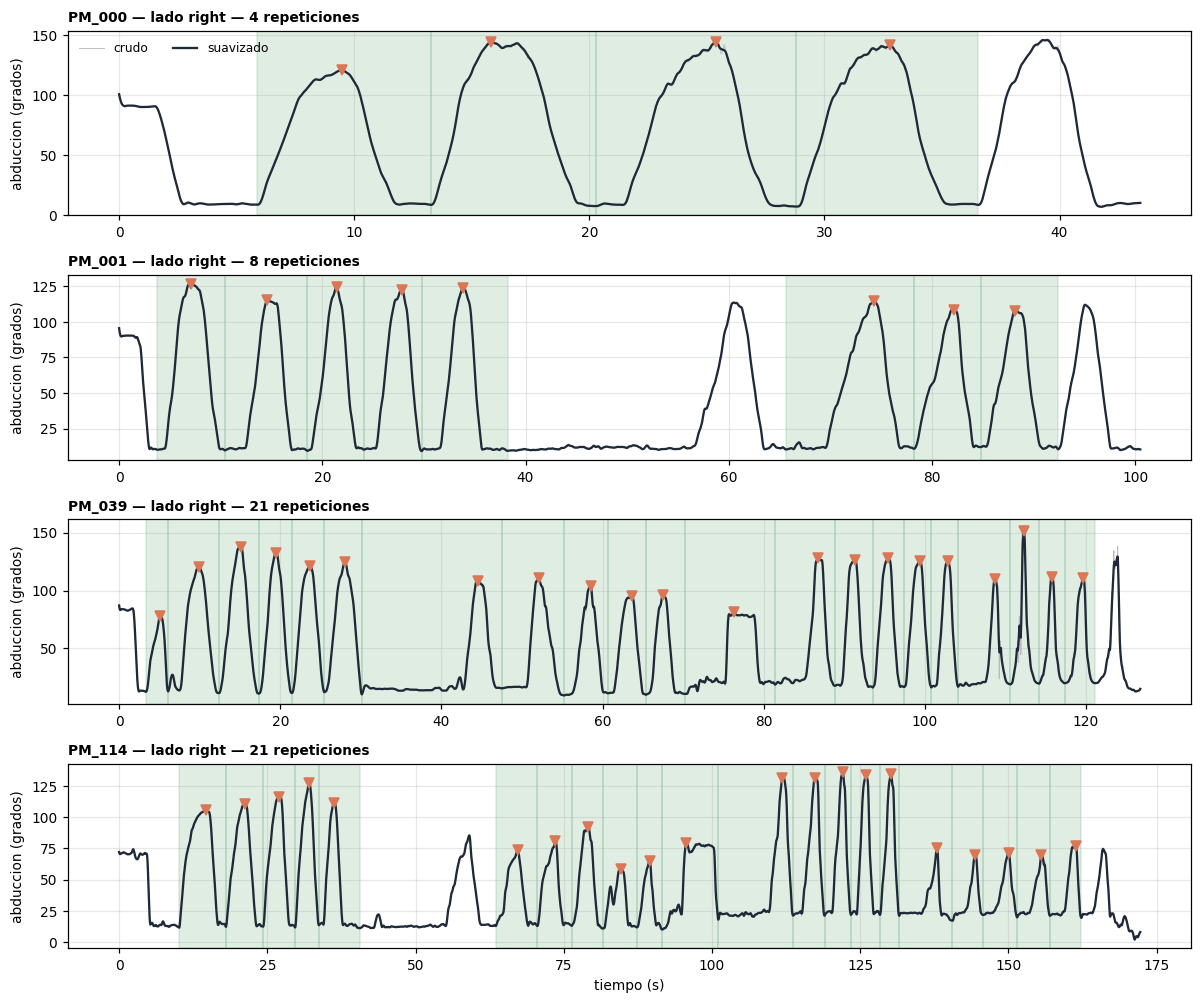

In [19]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # Grafico de validacion: si la segmentacion falla, todo lo posterior no sirve.
    sujetos_muestra = resumen_seg.sort_values("n_reps").sujeto.tolist()
    sujetos_muestra = sujetos_muestra[:2] + sujetos_muestra[-2:]
    fig, axes = plt.subplots(len(sujetos_muestra), 1,
                             figsize=(11, 2.3 * len(sujetos_muestra)), sharex=False)
    for ax, sujeto in zip(np.atleast_1d(axes), sujetos_muestra):
        fila = df_videos[(df_videos.sujeto == sujeto) & (df_videos.vista == "frontal")].iloc[0]
        s = series_cache[fila.video_id]
        ax.plot(s.t_seg, s.abduccion_hombro, lw=0.6, color="#bbb", label="crudo")
        ax.plot(s.t_seg, s.abduccion_suave, lw=1.5, color="#1f2937", label="suavizado")
        for i, r in enumerate(segmentos[sujeto]):
            ax.axvspan(s.t_seg[r["inicio"]], s.t_seg[r["fin"]], color="#4F9D69", alpha=0.18)
            ax.plot(s.t_seg[r["pico"]], s.abduccion_suave[r["pico"]], "v", color="#D97757", ms=6)
        ax.set_title(f"{sujeto} — lado {LADO_ACTIVO[sujeto]} — {len(segmentos[sujeto])} repeticiones",
                     loc="left", fontsize=9, fontweight="bold")
        ax.set_ylabel("abduccion (grados)")
    np.atleast_1d(axes)[0].legend(frameon=False, ncol=2, fontsize=8)
    np.atleast_1d(axes)[-1].set_xlabel("tiempo (s)")
    plt.tight_layout(); plt.savefig(FIG_DIR / "segmentacion.png", bbox_inches="tight"); plt.show()

---
## 6. Analisis exploratorio (EDA)

El objetivo no es hacer graficos bonitos: es decidir si los datos soportan un modelo.
La pregunta critica esta en 6.5.

### 6.0 Punto de entrada sin vídeos

Si las secciones 3 a 5 se saltaron por no tener los vídeos, `df_reps` se
reconstruye aquí desde el dataset ya calculado. Es el mismo objeto: una fila por
repetición y vista, con sus variables y su etiqueta.

De este punto en adelante el notebook no vuelve a tocar vídeo, así que el
análisis, el etiquetado, el modelado y la exportación funcionan igual.

In [ ]:
# 6.0 Reconstruccion de df_reps desde disco cuando no se ejecutaron 3-5.
#     Idempotente: si df_reps ya existe en memoria, no toca nada.
if "df_reps" in dir() and isinstance(globals().get("df_reps"), pd.DataFrame):
    print(f"df_reps ya esta en memoria: {len(df_reps)} repeticiones.")
elif HAY_DATASET:
    reps = pd.read_csv(DATASET_DIR / "ex1_repeticiones.csv")
    etiquetas_csv = DATASET_DIR / "ex1_etiquetas.csv"
    if etiquetas_csv.exists():
        # La etiqueta se guarda por gesto (el mismo movimiento visto por las dos
        # camaras), asi que hay que reunirla con las filas por repeticion.
        etiquetas = pd.read_csv(etiquetas_csv)[["gesto_id", "etiqueta"]]
        df_reps = reps.merge(etiquetas, on="gesto_id", how="left")
        sin_etiqueta = int(df_reps.etiqueta.isna().sum())
        if sin_etiqueta:
            print(f"AVISO: {sin_etiqueta} repeticiones sin etiqueta, se descartan.")
            df_reps = df_reps[df_reps.etiqueta.notna()]
    else:
        df_reps = reps
    df_reps = df_reps.reset_index(drop=True)
    VARIABLES = [c for c in df_reps.columns
                 if df_reps[c].dtype.kind in "fiu" and c not in ("y",)]
    print(f"df_reps reconstruido desde disco: {len(df_reps)} repeticiones, "
          f"{df_reps.sujeto.nunique()} sujetos")
else:
    df_reps = pd.DataFrame()
    VARIABLES = []
    print("Sin dataset: las secciones 6 a 13 se saltaran. Se conservan como")
    print("documentacion del metodo; monta los datos para ejecutarlas.")

HAY_REPS = len(df_reps) > 0

In [20]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 6.1 Descriptivos por sujeto
    desc = []
    for fila in df_videos[df_videos.video_id.isin(VIDEOS_VALIDOS)].itertuples():
        s = series_cache[fila.video_id]
        v = s[s.valido]
        desc.append({
            "sujeto": fila.sujeto, "vista": fila.vista, "lado": LADO_ACTIVO[fila.sujeto],
            "n_reps": len(segmentos[fila.sujeto]),
            "dur_s": fila.duracion_s,
            "rom_max": v.abduccion_hombro.max(),
            "rom_medio": v.abduccion_hombro.mean(),
            "codo_medio": v.flexion_codo.mean(),
            "tronco_max": v.inclinacion_tronco.max(),
            "frac_valida": s.valido.mean(),
        })
    df_desc = pd.DataFrame(desc)
    display(df_desc.round(1).sort_values(["sujeto", "vista"]))

,sujeto,vista,lado,n_reps,dur_s,rom_max,rom_medio,codo_medio,tronco_max,frac_valida
0,PM_000,frontal,right,4,43.5,146.7,67.5,154.3,24.4,1.0
1,PM_000,lateral,right,4,43.5,159.9,30.4,137.9,9.3,1.0
2,PM_001,frontal,right,8,100.5,127.0,44.6,156.8,22.0,1.0
3,PM_001,lateral,right,8,100.5,73.3,13.6,137.4,11.1,1.0
4,PM_002,frontal,right,8,66.5,126.5,42.7,158.7,19.3,1.0
5,PM_002,lateral,right,8,66.5,101.8,36.8,146.1,8.9,1.0
6,PM_012,frontal,right,8,80.1,136.8,42.3,152.4,21.7,1.0
7,PM_012,lateral,right,8,80.1,123.2,14.3,141.0,8.3,1.0
8,PM_016,frontal,right,9,68.1,118.1,48.2,150.7,9.7,1.0
9,PM_016,lateral,right,9,68.1,121.3,37.8,145.1,6.8,1.0


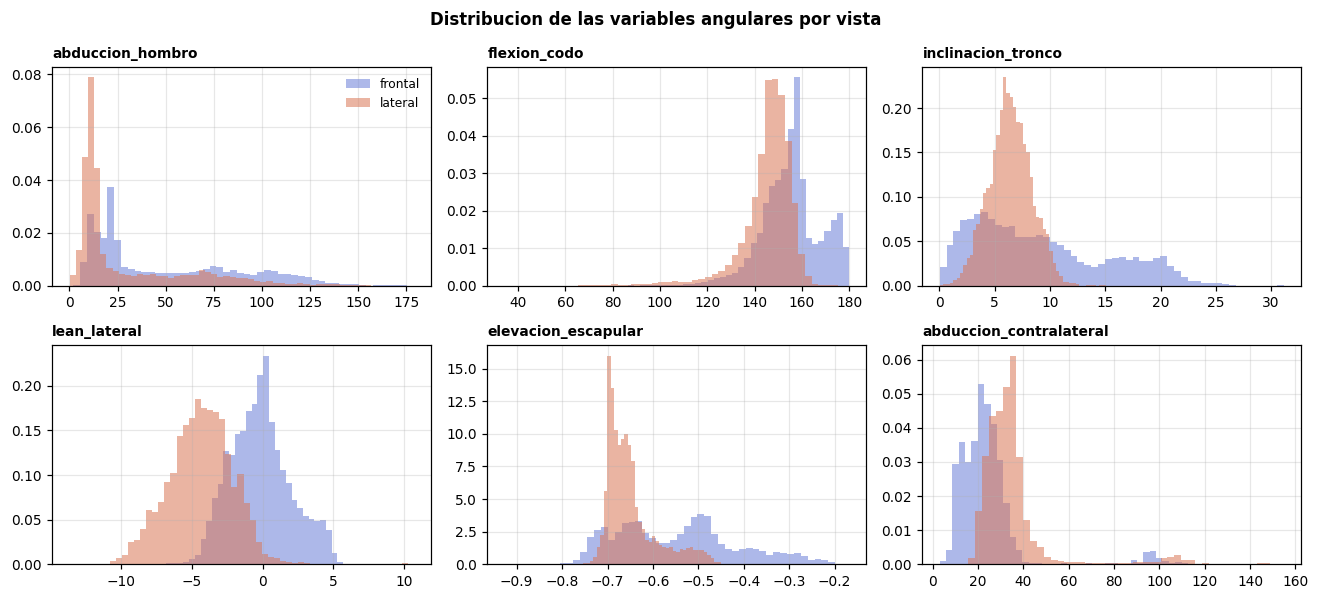

In [21]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # 6.2 Distribuciones de las variables angulares (todos los frames validos)
    variables = ["abduccion_hombro", "flexion_codo", "inclinacion_tronco",
                 "lean_lateral", "elevacion_escapular", "abduccion_contralateral"]
    todos = pd.concat([series_cache[v][series_cache[v].valido].assign(
        video_id=v, vista=df_videos.set_index("video_id").loc[v, "vista"],
        sujeto=df_videos.set_index("video_id").loc[v, "sujeto"])
        for v in VIDEOS_VALIDOS], ignore_index=True)

    fig, axes = plt.subplots(2, 3, figsize=(12, 5.5))
    for ax, var in zip(axes.ravel(), variables):
        for vista, color in [("frontal", "#6B7FD7"), ("lateral", "#D97757")]:
            d = todos.loc[todos.vista == vista, var].dropna()
            if len(d):
                ax.hist(d, bins=50, alpha=0.55, color=color, label=vista, density=True)
        ax.set_title(var, fontsize=9, fontweight="bold", loc="left")
    axes[0, 0].legend(frameon=False, fontsize=8)
    fig.suptitle("Distribucion de las variables angulares por vista", fontweight="bold")
    plt.tight_layout(); plt.savefig(FIG_DIR / "eda_distribuciones.png", bbox_inches="tight"); plt.show()

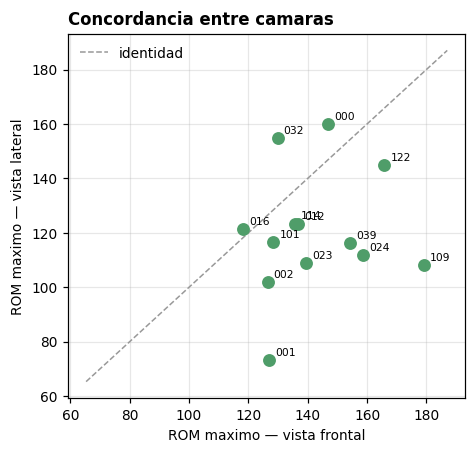

r = 0.15 | sesgo medio lateral-frontal = -21.7 grados (DE 26.9)
Si el sesgo es grande, la vista NO es ruido: hay que incluirla como variable.


In [22]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # 6.3 Concordancia entre vistas: el mismo gesto medido desde dos angulos
    piv = df_desc.pivot_table(index="sujeto", columns="vista", values="rom_max")
    if {"frontal", "lateral"}.issubset(piv.columns):
        piv = piv.dropna()
        fig, ax = plt.subplots(figsize=(4.4, 4.2))
        ax.scatter(piv.frontal, piv.lateral, s=55, color="#4F9D69", zorder=3)
        lims = [min(piv.min()) - 8, max(piv.max()) + 8]
        ax.plot(lims, lims, "--", color="#999", lw=1, label="identidad")
        for s, r in piv.iterrows():
            ax.annotate(s.replace("PM_", ""), (r.frontal, r.lateral), fontsize=7,
                        xytext=(4, 3), textcoords="offset points")
        ax.set_xlabel("ROM maximo — vista frontal"); ax.set_ylabel("ROM maximo — vista lateral")
        ax.set_title("Concordancia entre camaras", loc="left", fontweight="bold")
        ax.legend(frameon=False); plt.tight_layout(); plt.show()
        r = np.corrcoef(piv.frontal, piv.lateral)[0, 1]
        dif = (piv.lateral - piv.frontal)
        print(f"r = {r:.2f} | sesgo medio lateral-frontal = {dif.mean():+.1f} grados "
              f"(DE {dif.std():.1f})")
        print("Si el sesgo es grande, la vista NO es ruido: hay que incluirla como variable.")

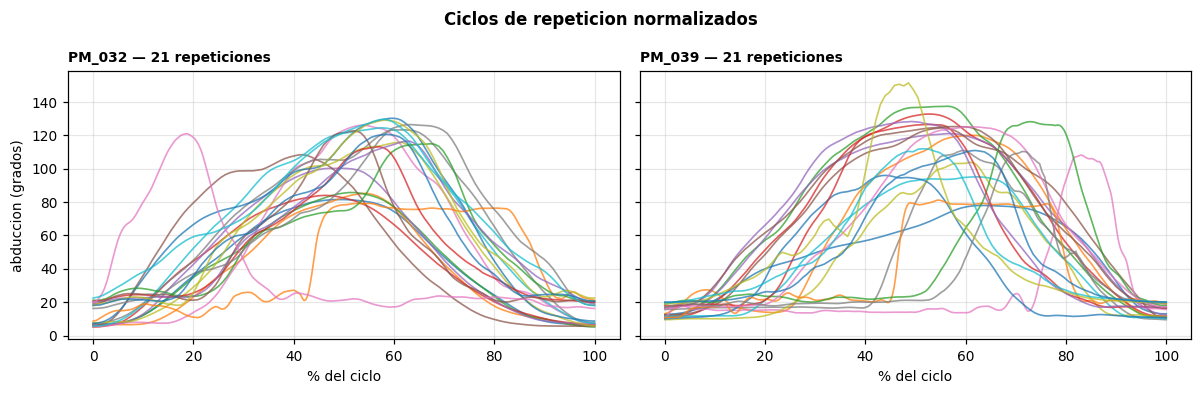

In [23]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    # 6.4 Ciclos normalizados superpuestos: variabilidad intra-sujeto real
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
    sujetos_plot = sorted(segmentos, key=lambda s: -len(segmentos[s]))[:2]
    for ax, sujeto in zip(axes, sujetos_plot):
        fila = df_videos[(df_videos.sujeto == sujeto) & (df_videos.vista == "frontal")].iloc[0]
        s = series_cache[fila.video_id]
        for i, r in enumerate(segmentos[sujeto]):
            y = s.abduccion_suave.to_numpy()[r["inicio"]:r["fin"] + 1]
            x = np.linspace(0, 100, len(y))
            ax.plot(x, y, lw=1.1, alpha=0.75)
        ax.set_title(f"{sujeto} — {len(segmentos[sujeto])} repeticiones",
                     loc="left", fontweight="bold", fontsize=9)
        ax.set_xlabel("% del ciclo")
    axes[0].set_ylabel("abduccion (grados)")
    fig.suptitle("Ciclos de repeticion normalizados", fontweight="bold")
    plt.tight_layout(); plt.savefig(FIG_DIR / "eda_ciclos.png", bbox_inches="tight"); plt.show()

### 6.5 Varianza intra-sujeto frente a inter-sujeto

**La pregunta que decide si el proyecto tiene sentido.** Si casi toda la varianza del
ROM esta *entre* sujetos y casi nada *dentro* de cada sujeto, el modelo aprendera a
identificar personas, no a evaluar la calidad del movimiento — y fallara con cualquier
paciente nuevo. Se cuantifica con el **coeficiente de correlacion intraclase (ICC)**:

- ICC alto (> 0.75): las repeticiones de una persona son casi identicas entre si.
  Poca senal intra-sujeto que aprender; el modelo tendera a memorizar sujetos.
- ICC moderado o bajo: hay variabilidad real dentro de cada persona. Es lo que se busca.

Esta celda se ejecuta despues de construir `df_reps` (seccion 7).

---
## 7. Feature engineering — variables por repeticion

Cada fila del dataset final es **una repeticion vista por una camara**. Las variables
se agrupan por lo que capturan clinicamente:

| Grupo | Variables | Que mide |
|---|---|---|
| Rango | `rom_max`, `rom_min`, `rom_range`, `rom_p95` | amplitud del movimiento |
| Codo | `codo_medio`, `codo_min`, `codo_std` | codo doblado = error tecnico clasico |
| Compensacion | `tronco_max`, `tronco_medio`, `lean_max`, `elevacion_escapular_max` | trampa postural |
| Simetria | `contralateral_max`, `contralateral_medio` | el otro brazo deberia quedarse quieto |
| Control motor | `duracion_s`, `ratio_con_exc`, `vel_pico`, `vel_media`, `suavidad_ldlj`, `tiempo_en_pico` | calidad de ejecucion |
| Contexto | `visibilidad_media`, `frac_valida`, `es_lateral`, `idx_rep`, `largo_torso` | calidad del dato y fatiga |

Dos decisiones que importan:

- **`elevacion_escapular`** (hombro que sube hacia la oreja) es la compensacion mas
  frecuente en elevacion de hombro y las reglas actuales de `src/classifier.py:66` **no
  la detectan**. Es una de las variables donde el modelo puede aportar valor real.
- **`suavidad_ldlj`** (*log dimensionless jerk*) es una metrica estandar de control motor
  en rehabilitacion. Captura descontrol del movimiento que ningun umbral angular ve.

In [24]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    from src.features_ex1 import features_repeticion, ldlj

    # features_repeticion() produce las variables por repeticion; es exactamente la
    # misma funcion que usa la app en tiempo real, por lo que no puede haber
    # desajuste entre lo que se entrena y lo que se sirve.
    print(f"{len(features_repeticion.__doc__.splitlines())} lineas de docstring; "
          "definicion unica en src/features_ex1.py")

13 lineas de docstring; definicion unica en src/features_ex1.py


In [25]:
# Requiere los videos originales (seccion 0). Sin ellos se salta y el
# notebook continua desde el dataset ya calculado (seccion 6.0).
if not HAY_VIDEOS:
    print("Se salta: no hay videos en", VIDEO_DIR)
else:
    filas = []
    for fila in df_videos[df_videos.video_id.isin(VIDEOS_VALIDOS)].itertuples():
        s = series_cache[fila.video_id]
        reps = segmentos.get(fila.sujeto, [])
        for i, rep in enumerate(reps):
            if rep["fin"] >= len(s):          # la vista puede tener 1-2 frames menos
                continue
            f = features_repeticion(s, rep, fila.fps, i, len(reps))
            if not f:
                continue
            f.update({
                "rep_id": f"{fila.sujeto}_r{i:02d}_{fila.vista}",
                "gesto_id": f"{fila.sujeto}_r{i:02d}",   # mismo gesto en ambas vistas
                "video_id": fila.video_id, "sujeto": fila.sujeto, "vista": fila.vista,
                "lado": LADO_ACTIVO[fila.sujeto],
                "es_lateral": int(fila.vista == "lateral"),
                "frame_ini": rep["inicio"], "frame_fin": rep["fin"], "frame_pico": rep["pico"],
            })
            filas.append(f)

    df_reps = pd.DataFrame(filas)
    META = ["rep_id", "gesto_id", "video_id", "sujeto", "vista", "lado",
            "frame_ini", "frame_fin", "frame_pico"]
    VARIABLES = [c for c in df_reps.columns if c not in META]

    df_reps = df_reps[META + VARIABLES]
    df_reps.to_csv(DATASET_DIR / "ex1_repeticiones.csv", index=False)

    print(f"df_reps: {len(df_reps)} repeticiones x {len(VARIABLES)} variables")
    print(f"  {df_reps.sujeto.nunique()} sujetos | {df_reps.gesto_id.nunique()} gestos unicos")
    print(df_reps.vista.value_counts().to_string())
    n_nan = df_reps[VARIABLES].isna().sum()
    if n_nan.sum():
        print("\nValores faltantes:"); print(n_nan[n_nan > 0].to_string())
    df_reps.head(3)

df_reps: 334 repeticiones x 28 variables
  13 sujetos | 167 gestos unicos
vista
frontal    167
lateral    167


,rep_id,gesto_id,video_id,sujeto,vista,lado,frame_ini,frame_fin,frame_pico,rom_max,...,vel_media,suavidad_ldlj,tiempo_en_pico,variabilidad_ang,visibilidad_media,frac_valida,largo_torso,idx_rep,n_reps_video,es_lateral
0,PM_000_r00_frontal,PM_000_r00,PM_000-Camera17-30fps,PM_000,frontal,right,176,398,284,120.813083,...,30.595005,-13.240296,0.264574,43.438583,0.996035,1.0,0.492501,0,4,0
1,PM_000_r01_frontal,PM_000_r01,PM_000-Camera17-30fps,PM_000,frontal,right,398,609,474,145.002067,...,39.702712,-13.270037,0.316038,51.682905,0.994774,1.0,0.491958,1,4,0
2,PM_000_r02_frontal,PM_000_r02,PM_000-Camera17-30fps,PM_000,frontal,right,609,864,762,144.664867,...,32.775429,-14.703009,0.179688,52.353748,0.995144,1.0,0.489952,2,4,0


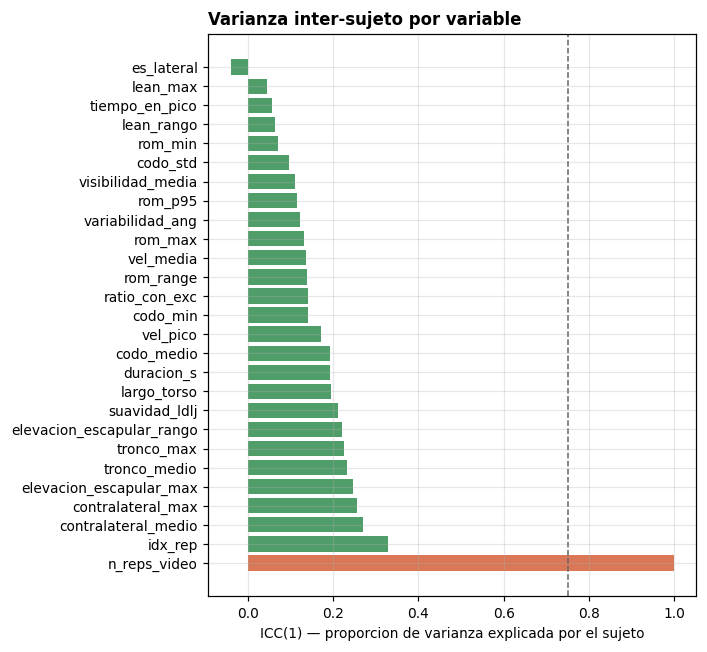

1/27 variables con ICC > 0.75 (dominadas por identidad del sujeto):
n_reps_video    1.0

Estas variables son las que mas riesgo tienen de convertir el modelo en un
identificador de personas. La validacion LOSO de la seccion 11 lo detectaria.


In [26]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 6.5 (ejecutado aqui, ya con df_reps) — ICC: varianza inter vs intra sujeto
    def icc1(df: pd.DataFrame, variable: str, grupo: str = "sujeto") -> float:
        d = df[[grupo, variable]].dropna()
        k = d.groupby(grupo).size().mean()
        media_global = d[variable].mean()
        medias = d.groupby(grupo)[variable].mean()
        n_g = d[grupo].nunique()
        if n_g < 2:
            return np.nan
        ms_entre = k * ((medias - media_global) ** 2).sum() / (n_g - 1)
        ms_dentro = d.groupby(grupo)[variable].apply(
            lambda x: ((x - x.mean()) ** 2).sum()).sum() / max(len(d) - n_g, 1)
        return float((ms_entre - ms_dentro) / (ms_entre + (k - 1) * ms_dentro))


    iccs = (pd.Series({v: icc1(df_reps, v) for v in VARIABLES})
            .dropna().sort_values(ascending=False))
    fig, ax = plt.subplots(figsize=(6.5, 6))
    colores = ["#D97757" if x > 0.75 else "#4F9D69" for x in iccs]
    ax.barh(iccs.index, iccs.values, color=colores)
    ax.axvline(0.75, ls="--", color="#666", lw=1)
    ax.set_xlabel("ICC(1) — proporcion de varianza explicada por el sujeto")
    ax.set_title("Varianza inter-sujeto por variable", loc="left", fontweight="bold")
    plt.tight_layout(); plt.savefig(FIG_DIR / "eda_icc.png", bbox_inches="tight"); plt.show()

    altas = iccs[iccs > 0.75]
    print(f"{len(altas)}/{len(iccs)} variables con ICC > 0.75 (dominadas por identidad del sujeto):")
    print(altas.round(2).to_string() if len(altas) else "  ninguna")
    print("\nEstas variables son las que mas riesgo tienen de convertir el modelo en un")
    print("identificador de personas. La validacion LOSO de la seccion 11 lo detectaria.")

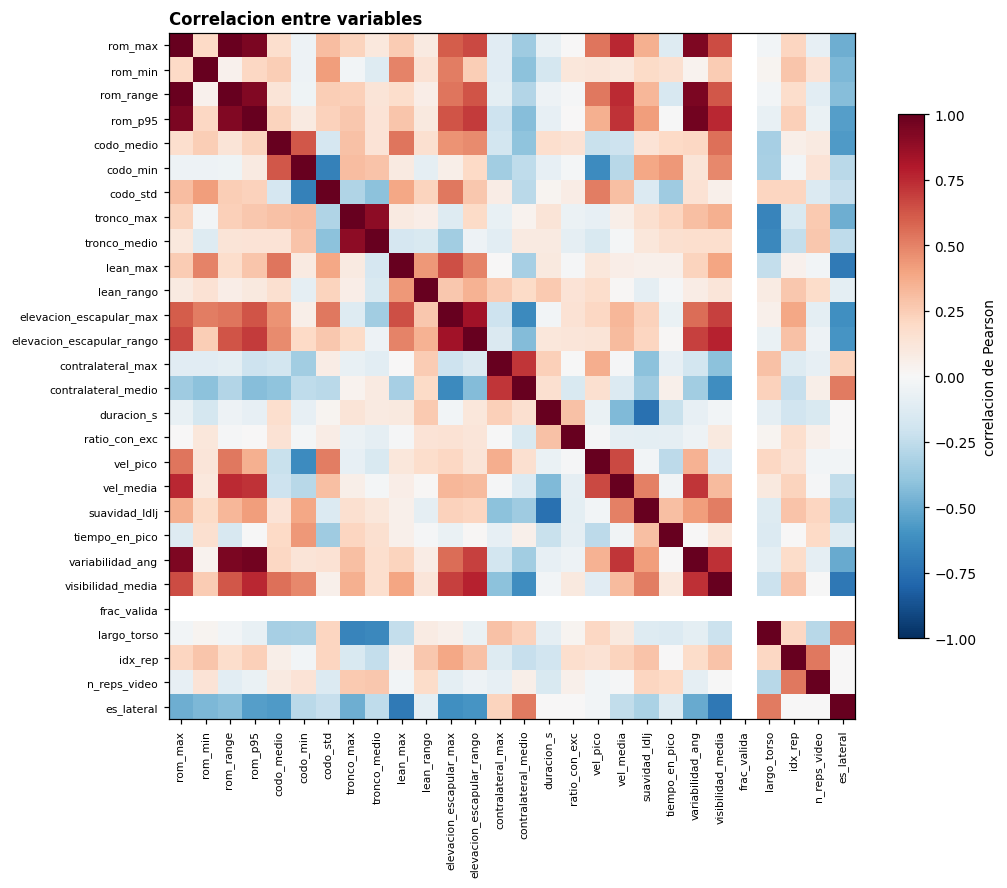

Pares mas correlacionados (candidatos a redundancia):
rom_range         rom_max             0.99
rom_max           rom_range           0.99
rom_p95           variabilidad_ang    0.97
variabilidad_ang  rom_p95             0.97
rom_range         variabilidad_ang    0.94
variabilidad_ang  rom_range           0.94
rom_max           rom_p95             0.94
rom_p95           rom_max             0.94


In [27]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Matriz de correlacion entre variables
    corr = df_reps[VARIABLES].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(9.5, 8))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.75, label="correlacion de Pearson")
    ax.set_title("Correlacion entre variables", loc="left", fontweight="bold")
    ax.grid(False)
    plt.tight_layout(); plt.savefig(FIG_DIR / "eda_correlacion.png", bbox_inches="tight"); plt.show()

    alta = (corr.abs().where(~np.eye(len(corr), dtype=bool)).stack()
            .sort_values(ascending=False).head(8))
    print("Pares mas correlacionados (candidatos a redundancia):")
    print(alta.round(2).to_string())

---
## 8. Etiquetado

**No existe ground truth en el proyecto.** Es la decision que determina si el modelo
vale algo. Este notebook implementa la estrategia **hibrida**:

1. Las reglas biomecanicas pre-etiquetan cada gesto (celda 8.1).
2. Se exporta `data/datasets/ex1_etiquetas.csv` con la propuesta y clips de revision.
3. Confirmas o corriges (celda 8.3, con `ipywidgets` o editando el CSV).
4. La celda 8.4 mide el **desacuerdo reglas vs. humano**, que es exactamente la senal
   que el XGBoost puede aprender y las reglas no.

> **Si saltas el paso 3**, el notebook funciona igual pero entrena sobre etiquetas
> generadas por reglas. Eso es **circular**: el XGBoost solo reaprende las reglas,
> la exactitud sale cercana al 100 % y no significa nada. La seccion 14 y el
> `model_card.md` registran automaticamente cual de los dos casos ocurrio.

In [28]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 8.1 Umbrales de las reglas. Calibrados a partir de la distribucion observada:
    #     revisa los percentiles impresos abajo y ajusta si tu criterio clinico difiere.
    p = df_reps[["rom_max", "tronco_max", "lean_max", "elevacion_escapular_max"]].describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    display(p.round(1))

    ROM_MINIMO = float(np.percentile(df_reps.rom_max.dropna(), 25))   # rango insuficiente
    TRONCO_LIMITE = float(np.percentile(df_reps.tronco_max.dropna(), 80))  # compensacion
    print(f"\nROM_MINIMO    = {ROM_MINIMO:.1f} grados  (percentil 25 del ROM maximo)")
    print(f"TRONCO_LIMITE = {TRONCO_LIMITE:.1f} grados  (percentil 80 de la inclinacion)")
    print("\nAjusta estos dos numeros a mano si tienes un criterio clinico especifico.")

,rom_max,tronco_max,lean_max,elevacion_escapular_max
count,334.0,334.0,334.0,334.0
mean,95.3,10.9,-0.8,-0.5
std,38.8,5.1,3.2,0.1
min,7.8,4.3,-7.7,-0.7
10%,17.9,6.3,-4.8,-0.7
25%,77.5,7.4,-3.0,-0.6
50%,105.4,9.3,-1.2,-0.5
75%,123.3,12.5,1.5,-0.4
90%,135.6,19.4,4.1,-0.3
max,179.0,29.1,6.5,-0.2



ROM_MINIMO    = 77.5 grados  (percentil 25 del ROM maximo)
TRONCO_LIMITE = 13.6 grados  (percentil 80 de la inclinacion)

Ajusta estos dos numeros a mano si tienes un criterio clinico especifico.


In [29]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    CLASES = {0: "rango_insuficiente", 1: "correcto", 2: "compensacion_tronco"}
    CLASE_A_ID = {v: k for k, v in CLASES.items()}


    def etiquetar_por_reglas(fila) -> str:
        # Mismo orden de decision que src/classifier.py:66, pero sobre angulos corregidos
        # y usando el ROM maximo de la repeticion en vez de la media del video.
        if fila.tronco_max > TRONCO_LIMITE:
            return "compensacion_tronco"
        if fila.rom_max < ROM_MINIMO:
            return "rango_insuficiente"
        return "correcto"


    df_reps["etiqueta_reglas"] = [etiquetar_por_reglas(f) for f in df_reps.itertuples()]

    # Una etiqueta por GESTO (no por vista): las dos camaras ven el mismo movimiento.
    # Se resuelve por la vista frontal, que es donde ambos brazos son visibles.
    por_gesto = (df_reps.sort_values("es_lateral")
                 .groupby("gesto_id")
                 .agg(sujeto=("sujeto", "first"),
                      etiqueta_reglas=("etiqueta_reglas", "first"),
                      rom_max=("rom_max", "max"), tronco_max=("tronco_max", "max"),
                      frame_ini=("frame_ini", "first"), frame_fin=("frame_fin", "first"))
                 .reset_index())
    df_reps["etiqueta_reglas"] = df_reps.gesto_id.map(
        dict(zip(por_gesto.gesto_id, por_gesto.etiqueta_reglas)))

    print(f"{len(por_gesto)} gestos unicos a etiquetar")
    print(por_gesto.etiqueta_reglas.value_counts().to_string())

167 gestos unicos a etiquetar
etiqueta_reglas
correcto               93
compensacion_tronco    67
rango_insuficiente      7


In [32]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 8.2 Archivo de revision. Se crea solo la primera vez; despues se conserva tu trabajo.
    ARCHIVO_ETIQUETAS = DATASET_DIR / "ex1_etiquetas.csv"

    COLS_ETIQUETA = ["gesto_id", "sujeto", "etiqueta_reglas", "rom_max", "tronco_max",
                     "frame_ini", "frame_fin", "etiqueta", "revisado"]

    plantilla = por_gesto[["gesto_id", "sujeto", "etiqueta_reglas",
                           "rom_max", "tronco_max", "frame_ini", "frame_fin"]].copy()
    plantilla["etiqueta"] = plantilla["etiqueta_reglas"]   # propuesta, a revisar
    plantilla["revisado"] = False

    if ARCHIVO_ETIQUETAS.exists():
        # Fusion, no sobrescritura: se conserva TODO el trabajo manual ya hecho y se
        # anaden los gestos nuevos. Sin esto, correr primero con un subconjunto de
        # sujetos dejaria un archivo incompleto y la seccion 8.4 descartaria en
        # silencio las repeticiones sin etiqueta.
        previo = pd.read_csv(ARCHIVO_ETIQUETAS)
        nuevos = plantilla[~plantilla.gesto_id.isin(previo.gesto_id)]
        df_etiquetas = pd.concat([previo, nuevos], ignore_index=True)
        huerfanos = set(previo.gesto_id) - set(plantilla.gesto_id)
        print(f"Archivo existente: {len(previo)} gestos "
              f"({int(previo.revisado.sum())} revisados)")
        if len(nuevos):
            print(f"  + {len(nuevos)} gestos nuevos anadidos")
        if huerfanos:
            print(f"  ! {len(huerfanos)} gestos del archivo ya no existen en los datos "
                  f"(cambio de segmentacion o de subset); se conservan pero no se usan")
    else:
        df_etiquetas = plantilla
        print(f"Creado {ARCHIVO_ETIQUETAS.relative_to(BASE_DIR)}")
        print("Edita la columna 'etiqueta' y marca 'revisado' = True en las filas que revises.")

    df_etiquetas = df_etiquetas[COLS_ETIQUETA]
    df_etiquetas.round(1).to_csv(ARCHIVO_ETIQUETAS, index=False)
    df_etiquetas = pd.read_csv(ARCHIVO_ETIQUETAS)
    print(f"\n{int(df_etiquetas.revisado.sum())}/{len(df_etiquetas)} gestos revisados a mano")
    df_etiquetas.head()

Archivo existente: 167 gestos (0 revisados)

0/167 gestos revisados a mano


,gesto_id,sujeto,etiqueta_reglas,rom_max,tronco_max,frame_ini,frame_fin,etiqueta,revisado
0,PM_000_r00,PM_000,compensacion_tronco,120.8,13.7,176,398,compensacion_tronco,False
1,PM_000_r01,PM_000,correcto,156.8,13.1,398,609,correcto,False
2,PM_000_r02,PM_000,correcto,152.9,12.8,609,864,correcto,False
3,PM_000_r03,PM_000,compensacion_tronco,152.2,14.1,864,1096,compensacion_tronco,False
4,PM_001_r00,PM_001,compensacion_tronco,127.0,14.8,113,313,compensacion_tronco,False


In [34]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 8.3 Tiras de contacto para revisar visualmente cada gesto.
    #     Genera un PNG por gesto con 6 frames del ciclo. Ejecutalo una vez.
    GENERAR_TIRAS = True   # ponlo en True para generar el material de revision
    TIRAS_DIR = FIG_DIR / "revision"

    if GENERAR_TIRAS:
        TIRAS_DIR.mkdir(parents=True, exist_ok=True)
        idx_video = df_videos.set_index(["sujeto", "vista"])
        for g in tqdm(list(por_gesto.itertuples()), desc="tiras"):
            destino = TIRAS_DIR / f"{g.gesto_id}.png"
            if destino.exists():
                continue
            try:
                fila = idx_video.loc[(g.sujeto, "frontal")]
            except KeyError:
                continue
            cap = cv2.VideoCapture(fila.path)
            muestras = np.linspace(g.frame_ini, g.frame_fin, 6).astype(int)
            imgs = []
            for n in muestras:
                cap.set(cv2.CAP_PROP_POS_FRAMES, int(n))
                ok, img = cap.read()
                if ok:
                    h, w = img.shape[:2]
                    imgs.append(cv2.cvtColor(cv2.resize(img, (320, int(320 * h / w))),
                                             cv2.COLOR_BGR2RGB))
            cap.release()
            if not imgs:
                continue
            fig, axes = plt.subplots(1, len(imgs), figsize=(2.0 * len(imgs), 2.6))
            for ax, im in zip(np.atleast_1d(axes), imgs):
                ax.imshow(im); ax.axis("off")
            fig.suptitle(f"{g.gesto_id} — propuesta: {g.etiqueta_reglas} "
                         f"(ROM {g.rom_max:.0f}, tronco {g.tronco_max:.0f})", fontsize=9)
            plt.tight_layout(); plt.savefig(destino, bbox_inches="tight", dpi=80); plt.close(fig)
        print(f"Tiras en {TIRAS_DIR}")
    else:
        print("GENERAR_TIRAS = False. Ponlo en True para producir el material de revision.")

tiras:   0%|          | 0/167 [00:00<?, ?it/s]

Tiras en /Users/dafnezepedagonzalez/Documents/Diplomado/Modulo5/physiovision_gradio/entrenamiento/figuras/revision


In [31]:
# 8.3b-bis El widget de etiquetado necesita ipywidgets. En Colab viene de serie;
#          en local se instala una vez. Sin el, la celda siguiente cae al modo
#          de edicion por CSV y el notebook sigue igual.
try:
    import ipywidgets  # noqa: F401
    print("ipywidgets disponible: el widget de etiquetado esta activo.")
except ImportError:
    import subprocess, sys
    print("Instalando ipywidgets...")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "ipywidgets"],
                   check=False)
    print("Instalado. Reinicia el kernel si el widget no aparece.")


  Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 8.3b Widget de etiquetado (opcional). Sin ipywidgets, edita el CSV a mano.
    try:
        import ipywidgets as widgets
        from IPython.display import display as _d, Image as _Img, clear_output
        HAY_WIDGETS = True
    except ImportError:
        HAY_WIDGETS = False
        print("ipywidgets no instalado — edita data/datasets/ex1_etiquetas.csv directamente.")

    if HAY_WIDGETS:
        estado = {"i": 0}
        salida = widgets.Output()

        def mostrar():
            with salida:
                clear_output(wait=True)
                if estado["i"] >= len(df_etiquetas):
                    print("Revision completa."); return
                fila = df_etiquetas.iloc[estado["i"]]
                print(f"[{estado['i']+1}/{len(df_etiquetas)}] {fila.gesto_id} | "
                      f"ROM {fila.rom_max:.0f} | tronco {fila.tronco_max:.0f} | "
                      f"propuesta: {fila.etiqueta_reglas}")
                img = TIRAS_DIR / f"{fila.gesto_id}.png"
                if img.exists():
                    _d(_Img(filename=str(img), width=780))

        def guardar(etiqueta):
            df_etiquetas.loc[estado["i"], "etiqueta"] = etiqueta
            df_etiquetas.loc[estado["i"], "revisado"] = True
            df_etiquetas.to_csv(ARCHIVO_ETIQUETAS, index=False)
            estado["i"] += 1
            mostrar()

        botones = [widgets.Button(description=c, button_style=b)
                   for c, b in [("correcto", "success"), ("rango_insuficiente", "warning"),
                                ("compensacion_tronco", "info")]]
        for b in botones:
            b.on_click(lambda x, d=b.description: guardar(d))
        saltar = widgets.Button(description="saltar", button_style="")
        saltar.on_click(lambda x: (estado.__setitem__("i", estado["i"] + 1), mostrar()))

        _d(widgets.HBox(botones + [saltar]), salida)
        mostrar()

Output()

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 8.4 Consolidacion y medida de circularidad
    df_etiquetas = pd.read_csv(ARCHIVO_ETIQUETAS)
    mapa_etiqueta = dict(zip(df_etiquetas.gesto_id, df_etiquetas.etiqueta))
    df_reps["etiqueta"] = df_reps.gesto_id.map(mapa_etiqueta)
    sin_etiqueta = int(df_reps.etiqueta.isna().sum())
    if sin_etiqueta:
        print(f"AVISO: {sin_etiqueta} repeticiones sin etiqueta, se excluyen del dataset.")
    df_reps = df_reps[df_reps.etiqueta.notna()].copy()
    df_reps["y"] = df_reps.etiqueta.map(CLASE_A_ID)

    N_REVISADOS = int(df_etiquetas.revisado.sum())
    ETIQUETADO_MANUAL = N_REVISADOS >= 0.5 * len(df_etiquetas)

    from sklearn.metrics import confusion_matrix, cohen_kappa_score

    orden = list(CLASES.values())
    cm = confusion_matrix(df_etiquetas.etiqueta_reglas, df_etiquetas.etiqueta, labels=orden)
    acuerdo = float((df_etiquetas.etiqueta_reglas == df_etiquetas.etiqueta).mean())
    kappa = cohen_kappa_score(df_etiquetas.etiqueta_reglas, df_etiquetas.etiqueta, labels=orden)

    print(f"Gestos revisados a mano : {N_REVISADOS}/{len(df_etiquetas)}")
    print(f"Acuerdo reglas vs final : {acuerdo:.1%}   (kappa = {kappa:.2f})")
    display(pd.DataFrame(cm, index=[f"reglas: {o}" for o in orden],
                         columns=[f"final: {o}" for o in orden]))

    if not ETIQUETADO_MANUAL:
        print("\n" + "!" * 72)
        print("AVISO METODOLOGICO: menos de la mitad de los gestos fueron revisados.")
        print("El modelo se esta entrenando esencialmente sobre etiquetas generadas por")
        print("reglas. Las metricas resultantes NO miden capacidad clinica: miden si el")
        print("XGBoost puede reaprender un arbol de decision de dos umbrales. Puede, y por")
        print("eso saldran cerca del 100%. Queda registrado en el model_card.")
        print("!" * 72)
    elif acuerdo > 0.95:
        print("\nAVISO: el acuerdo supera el 95%. Queda muy poca senal fuera de las reglas;")
        print("la ganancia del XGBoost sera marginal por construccion.")

    print()
    print(df_reps.etiqueta.value_counts().to_string())
    print(f"\nDesbalance: clase mayoritaria = {df_reps.etiqueta.value_counts(normalize=True).max():.1%}")

---
## 9. Particion y baselines

**Particion: `LeaveOneGroupOut` agrupado por sujeto (LOSO).** Con ~13 sujetos es la
evaluacion de menor varianza y responde a la pregunta real: *funciona con un paciente
que el modelo nunca vio?*

Un `train_test_split` aleatorio aqui daria metricas fantasiosas: las ~15 repeticiones de
una persona y sus dos vistas son casi duplicados, y acabarian repartidas entre
entrenamiento y prueba.

**Baselines obligatorios.** Sin ellos el numero final no se puede interpretar:

| Baseline | Que responde |
|---|---|
| `DummyClassifier` | el suelo |
| **Reglas de `src/classifier.py:66`** | el rival real — el sistema que ya existe |
| `LogisticRegression` | hace falta un modelo no lineal? |
| `RandomForest` | referencia de ensamble |
| **XGBoost** | el objetivo |

Si XGBoost no supera a las reglas, la conclusion honesta es que las reglas bastan.
Ese resultado tambien es un resultado.

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    from sklearn.dummy import DummyClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                                 matthews_corrcoef, classification_report)
    from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.utils.class_weight import compute_sample_weight
    from xgboost import XGBClassifier

    # El contrato de variables se congela AQUI. Todo lo que venga despues lo respeta.
    # Variables excluidas del contrato:
    #  - idx_rep, n_reps_video: indices crudos, no generalizan a otro video.
    #  - progreso_serie: vale idx_rep/(n_reps_video-1), asi que necesita conocer el
    #    total de repeticiones de la serie. En clasificacion en vivo ese dato no
    #    existe hasta que el usuario termina, de modo que NO es calculable de forma
    #    causal. Dejarla dentro obligaria a inventar un valor en inferencia y
    #    produciria un desajuste train/serve silencioso. Ver cont/PLAN.md, 9.1.
    EXCLUIR = ["idx_rep", "n_reps_video", "progreso_serie"]
    FEATURES = [c for c in VARIABLES if c not in EXCLUIR and c not in ("etiqueta_reglas",)]
    FEATURES = [c for c in FEATURES if df_reps[c].dtype.kind in "fiu"]

    X = df_reps[FEATURES].astype(float)
    y = df_reps["y"].astype(int).to_numpy()
    grupos = df_reps["sujeto"].to_numpy()

    # XGBoost >= 3 exige que las clases de y sean enteros contiguos 0..K-1. Si alguna
    # clase no aparece en absoluto en los datos, hay que recodificar y dejar constancia.
    CLASES_PRESENTES = sorted(np.unique(y).tolist())
    if CLASES_PRESENTES != list(range(len(CLASES_PRESENTES))):
        remapeo = {viejo: nuevo for nuevo, viejo in enumerate(CLASES_PRESENTES)}
        print(f"AVISO: clases ausentes en los datos. Remapeando {remapeo}")
        y = np.array([remapeo[v] for v in y])
        CLASES = {remapeo[k]: v for k, v in CLASES.items() if k in remapeo}
        CLASE_A_ID = {v: k for k, v in CLASES.items()}
        df_reps["y"] = y

    # Imputacion simple de los pocos NaN (suavidad_ldlj puede fallar en reps muy cortas).
    MEDIANAS = X.median()
    X = X.fillna(MEDIANAS)

    print(f"X: {X.shape[0]} repeticiones x {X.shape[1]} variables")
    print(f"y: {dict(pd.Series(y).map(CLASES).value_counts())}")
    print(f"grupos: {len(np.unique(grupos))} sujetos")
    print(f"\nVariables ({len(FEATURES)}):\n  " + ", ".join(FEATURES))

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    logo = LeaveOneGroupOut()
    N_GRUPOS = len(np.unique(grupos))
    print(f"Validacion LOSO: {logo.get_n_splits(groups=grupos)} folds "
          f"(uno por sujeto, {N_GRUPOS} sujetos)")


    from sklearn.base import BaseEstimator, ClassifierMixin
    from sklearn.preprocessing import LabelEncoder


    class XGBSeguro(BaseEstimator, ClassifierMixin):
        # XGBoost >= 3 rechaza y si sus clases no son 0..K-1 contiguas. En un fold LOSO
        # una clase rara puede faltar del conjunto de entrenamiento, asi que se recodifica
        # antes de ajustar y se deshace al predecir. predict_proba devuelve las columnas
        # de las clases vistas en ese fold; evaluar_loso las recoloca en las globales.
        def __init__(self, **params):
            self.params = params

        def get_params(self, deep=True):
            return {"params": self.params}

        def set_params(self, **kwargs):
            self.params.update(kwargs.pop("params", {}) or {})
            self.params.update(kwargs)
            return self

        def fit(self, X, y, sample_weight=None):
            self._le = LabelEncoder().fit(y)
            self.classes_ = self._le.classes_
            params = dict(self.params)
            # Con solo dos clases presentes en el fold, multi:softprob deja num_class
            # en 0 y XGBoost falla: hay que bajar al objetivo binario.
            if len(self.classes_) <= 2:
                params["objective"] = "binary:logistic"
                params["eval_metric"] = "logloss"
            self.inner = XGBClassifier(**params)
            self.inner.fit(X, self._le.transform(y), sample_weight=sample_weight)
            return self

        def predict(self, X):
            return self._le.inverse_transform(self.inner.predict(X))

        def predict_proba(self, X):
            return self.inner.predict_proba(X)


    def ajustar(modelo, X_tr, y_tr, usar_pesos=True):
        # Los Pipeline de sklearn rechazan sample_weight en fit() (hay que enrutarlo por
        # nombre de paso). En esos casos se usa el class_weight='balanced' ya configurado.
        if usar_pesos:
            try:
                return modelo.fit(X_tr, y_tr,
                                  sample_weight=compute_sample_weight("balanced", y_tr))
            except (TypeError, ValueError):
                pass
        return modelo.fit(X_tr, y_tr)


    def evaluar_loso(modelo_fn, X, y, grupos, usar_pesos=True, nombre=""):
        # Devuelve las predicciones out-of-fold de todos los sujetos.
        pred = np.zeros(len(y), dtype=int)
        proba = np.zeros((len(y), len(CLASES)))
        for tr, te in logo.split(X, y, grupos):
            modelo = ajustar(modelo_fn(), X.iloc[tr], y[tr], usar_pesos)
            pred[te] = modelo.predict(X.iloc[te])
            if hasattr(modelo, "predict_proba"):
                p = modelo.predict_proba(X.iloc[te])
                for j, c in enumerate(modelo.classes_):
                    proba[te, int(c)] = p[:, j]
        return pred, proba


    def metricas(y_true, y_pred, nombre=""):
        return {
            "modelo": nombre,
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "balanced_acc": balanced_accuracy_score(y_true, y_pred),
            "accuracy": accuracy_score(y_true, y_pred),
            "mcc": matthews_corrcoef(y_true, y_pred),
        }

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Baseline 2: las reglas heuristicas que ya usa la app, evaluadas sobre las mismas filas.
    pred_reglas = df_reps.apply(
        lambda f: CLASE_A_ID[etiquetar_por_reglas(f)], axis=1).to_numpy()

    resultados = [metricas(y, pred_reglas, "reglas (src/classifier.py)")]

    candidatos = {
        "dummy (estratificado)": lambda: DummyClassifier(strategy="stratified", random_state=SEED),
        "regresion logistica": lambda: make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced",
                                                 random_state=SEED)),
        "random forest": lambda: RandomForestClassifier(
            n_estimators=400, min_samples_leaf=3, class_weight="balanced_subsample",
            random_state=SEED, n_jobs=-1),
        "xgboost (por defecto)": lambda: XGBSeguro(
            objective="multi:softprob", tree_method="hist", eval_metric="mlogloss",
            random_state=SEED, n_estimators=300, max_depth=4, learning_rate=0.1,
            verbosity=0),
    }

    predicciones = {"reglas (src/classifier.py)": pred_reglas}
    for nombre, fn in candidatos.items():
        pred, _ = evaluar_loso(fn, X, y, grupos, nombre=nombre)
        predicciones[nombre] = pred
        resultados.append(metricas(y, pred, nombre))

    df_base = pd.DataFrame(resultados).sort_values("macro_f1", ascending=False)
    display(df_base.set_index("modelo").round(3)
            .style.background_gradient(cmap="Greens", axis=0))

### 9.1 Ablacion: el modelo aporta algo mas alla de las reglas?

Las reglas usan exactamente dos variables: `tronco_max` y `rom_max`. Si el XGBoost solo
las esta reaprendiendo, al **quitarselas** su rendimiento deberia desplomarse. Si se
mantiene alto, es que ha encontrado senal en las otras variables — elevacion escapular,
suavidad, simetria — y ahi esta su valor real.

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    VARIABLES_DE_REGLA = ["tronco_max", "rom_max", "rom_p95", "tronco_medio"]
    X_ablacion = X.drop(columns=[c for c in VARIABLES_DE_REGLA if c in X.columns])

    pred_abl, _ = evaluar_loso(candidatos["xgboost (por defecto)"], X_ablacion, y, grupos)
    m_full = metricas(y, predicciones["xgboost (por defecto)"], "xgboost completo")
    m_abl = metricas(y, pred_abl, "xgboost sin variables de regla")

    display(pd.DataFrame([m_full, m_abl]).set_index("modelo").round(3))
    caida = m_full["macro_f1"] - m_abl["macro_f1"]
    print(f"Caida de macro-F1 al quitar las variables de regla: {caida:+.3f}")
    print("Caida grande  -> el modelo depende de las reglas (riesgo de circularidad).")
    print("Caida pequena -> hay senal independiente en las demas variables.")

---
## 10. Hiperparametrizacion

**Validacion cruzada anidada**: la busqueda se hace en un `StratifiedGroupKFold` interno
y la evaluacion final en el LOSO externo (seccion 11). Sin este anidamiento, los
hiperparametros ven los datos de prueba y las metricas salen optimistas.

El espacio de busqueda esta sesgado a **modelos pequenos y muy regularizados** porque
n es de unos cientos y p de unas veinte variables: arboles profundos memorizarian los
sujetos.

Usa `optuna` si esta instalado (mejor eficiencia de muestreo y graficos de importancia
de hiperparametros); si no, cae a `RandomizedSearchCV`.

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    N_TRIALS = 120

    ESPACIO = {
        "max_depth": (2, 6),
        "learning_rate": (0.01, 0.3),
        "n_estimators": (100, 800),
        "min_child_weight": (1, 20),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.5, 1.0),
        "gamma": (0.0, 5.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
    }

    # num_class NO se fija: en un fold LOSO puede faltar una clase rara en el conjunto
    # de entrenamiento, y XGBClassifier exige que las clases de y sean 0..n-1 contiguas.
    # Dejandolo inferir, la API sklearn hace la correspondencia via classes_ y
    # evaluar_loso() recoloca las probabilidades en las columnas globales correctas.
    FIJOS = dict(objective="multi:softprob", tree_method="hist",
                 eval_metric="mlogloss", random_state=SEED, verbosity=0, n_jobs=-1)

    # CV interna: no puede tener mas folds que sujetos disponibles.
    N_SPLITS_INT = int(min(4, max(2, N_GRUPOS - 1)))
    cv_interna = StratifiedGroupKFold(n_splits=N_SPLITS_INT, shuffle=True, random_state=SEED)
    print(f"CV interna: StratifiedGroupKFold({N_SPLITS_INT}) agrupado por sujeto")


    def objetivo_cv(params, X, y, grupos, cv) -> float:
        scores = []
        for tr, te in cv.split(X, y, grupos):
            m = ajustar(XGBSeguro(**FIJOS, **params), X.iloc[tr], y[tr])
            scores.append(f1_score(y[te], m.predict(X.iloc[te]), average="macro",
                                   zero_division=0))
        return float(np.mean(scores))

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        HAY_OPTUNA = True
    except ImportError:
        HAY_OPTUNA = False
        print("optuna no instalado — se usa RandomizedSearchCV.")

    t0 = time.time()

    if HAY_OPTUNA:
        def objetivo(trial):
            params = {
                "max_depth": trial.suggest_int("max_depth", *ESPACIO["max_depth"]),
                "learning_rate": trial.suggest_float("learning_rate", *ESPACIO["learning_rate"], log=True),
                "n_estimators": trial.suggest_int("n_estimators", *ESPACIO["n_estimators"], step=50),
                "min_child_weight": trial.suggest_int("min_child_weight", *ESPACIO["min_child_weight"]),
                "subsample": trial.suggest_float("subsample", *ESPACIO["subsample"]),
                "colsample_bytree": trial.suggest_float("colsample_bytree", *ESPACIO["colsample_bytree"]),
                "gamma": trial.suggest_float("gamma", *ESPACIO["gamma"]),
                "reg_alpha": trial.suggest_float("reg_alpha", *ESPACIO["reg_alpha"], log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", *ESPACIO["reg_lambda"], log=True),
            }
            return objetivo_cv(params, X, y, grupos, cv_interna)

        estudio = optuna.create_study(direction="maximize",
                                      sampler=optuna.samplers.TPESampler(seed=SEED),
                                      pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
        estudio.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=True)
        MEJORES = estudio.best_params
        mejor_score = estudio.best_value
    else:
        # Busqueda aleatoria manual sobre el mismo espacio y la misma CV interna.
        # No se usa RandomizedSearchCV porque clona el estimador y vuelve a tropezar
        # con el problema de clases no contiguas por fold.
        rng_busq = np.random.default_rng(SEED)
        MEJORES, mejor_score = None, -np.inf
        for t in tqdm(range(N_TRIALS), desc="busqueda aleatoria"):
            params = {
                "max_depth": int(rng_busq.integers(*ESPACIO["max_depth"])),
                "learning_rate": float(np.exp(rng_busq.uniform(
                    *np.log(ESPACIO["learning_rate"])))),
                "n_estimators": int(rng_busq.integers(
                    ESPACIO["n_estimators"][0] // 50, ESPACIO["n_estimators"][1] // 50) * 50),
                "min_child_weight": int(rng_busq.integers(*ESPACIO["min_child_weight"])),
                "subsample": float(rng_busq.uniform(*ESPACIO["subsample"])),
                "colsample_bytree": float(rng_busq.uniform(*ESPACIO["colsample_bytree"])),
                "gamma": float(rng_busq.uniform(*ESPACIO["gamma"])),
                "reg_alpha": float(np.exp(rng_busq.uniform(*np.log(ESPACIO["reg_alpha"])))),
                "reg_lambda": float(np.exp(rng_busq.uniform(*np.log(ESPACIO["reg_lambda"])))),
            }
            score = objetivo_cv(params, X, y, grupos, cv_interna)
            if score > mejor_score:
                MEJORES, mejor_score = params, score

    print(f"\nBusqueda terminada en {(time.time()-t0)/60:.1f} min")
    print(f"Mejor macro-F1 en CV interna: {mejor_score:.3f}")
    for k, v in MEJORES.items():
        print(f"  {k:20s} {v}")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Importancia de los hiperparametros e historia de la optimizacion (solo con optuna).
    if HAY_OPTUNA:
        hist = [t.value for t in estudio.trials if t.value is not None]
        fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
        axes[0].plot(hist, lw=0.9, color="#999", label="trial")
        axes[0].plot(np.maximum.accumulate(hist), lw=2, color="#4F9D69", label="mejor acumulado")
        axes[0].set_xlabel("trial"); axes[0].set_ylabel("macro-F1 (CV interna)")
        axes[0].set_title("Historia de la optimizacion", loc="left", fontweight="bold")
        axes[0].legend(frameon=False)
        try:
            imp = optuna.importance.get_param_importances(estudio)
            axes[1].barh(list(imp)[::-1], list(imp.values())[::-1], color="#6B7FD7")
            axes[1].set_title("Importancia de hiperparametros", loc="left", fontweight="bold")
        except Exception as e:
            axes[1].text(0.5, 0.5, f"no disponible\n{e}", ha="center"); axes[1].axis("off")
        plt.tight_layout(); plt.savefig(FIG_DIR / "optuna.png", bbox_inches="tight"); plt.show()

---
## 11. Entrenamiento final y evaluacion LOSO

Con los hiperparametros elegidos se recorre el LOSO externo, acumulando las predicciones
**out-of-fold** de los 13 sujetos. Sobre ese conjunto se calculan todas las metricas.

Metrica principal: **macro-F1**, no exactitud. Con clases desbalanceadas la exactitud
premia predecir siempre la clase mayoritaria.

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Para la evaluacion por folds se usa el envoltorio; el modelo final (celda de mas
    # abajo) es un XGBClassifier normal, porque sobre el total si estan todas las clases
    # y asi se exporta con save_model() sin capas intermedias.
    crear_xgb = lambda: XGBSeguro(**FIJOS, **MEJORES)

    pred_oof, proba_oof = evaluar_loso(crear_xgb, X, y, grupos)
    m_final = metricas(y, pred_oof, "xgboost (optimizado)")

    comparativa = pd.DataFrame(resultados + [m_final]).drop_duplicates(
        subset="modelo", keep="last").sort_values("macro_f1", ascending=False)
    display(comparativa.set_index("modelo").round(3)
            .style.background_gradient(cmap="Greens", axis=0))

    print("\n" + classification_report(y, pred_oof,
                                       target_names=[CLASES[i] for i in sorted(CLASES)],
                                       zero_division=0))

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Intervalos de confianza por bootstrap sobre las predicciones out-of-fold.
    def bootstrap_ic(y_true, y_pred, metrica_fn, n=2000, alfa=0.05):
        rng = np.random.default_rng(SEED)
        vals = []
        for _ in range(n):
            idx = rng.integers(0, len(y_true), len(y_true))
            if len(np.unique(y_true[idx])) < 2:
                continue
            vals.append(metrica_fn(y_true[idx], y_pred[idx]))
        return float(np.percentile(vals, 100 * alfa / 2)), float(np.percentile(vals, 100 * (1 - alfa / 2)))


    f1_macro = lambda a, b: f1_score(a, b, average="macro", zero_division=0)
    ic_xgb = bootstrap_ic(y, pred_oof, f1_macro)
    ic_reglas = bootstrap_ic(y, pred_reglas, f1_macro)

    print(f"macro-F1 XGBoost : {m_final['macro_f1']:.3f}  IC95% [{ic_xgb[0]:.3f}, {ic_xgb[1]:.3f}]")
    print(f"macro-F1 reglas  : {resultados[0]['macro_f1']:.3f}  IC95% [{ic_reglas[0]:.3f}, {ic_reglas[1]:.3f}]")
    if ic_xgb[0] > resultados[0]["macro_f1"]:
        print("\nEl IC del XGBoost no incluye el valor de las reglas: la mejora es consistente.")
    else:
        print("\nLos intervalos se solapan: la mejora sobre las reglas NO es concluyente")
        print("con esta cantidad de datos. Declararlo asi en las conclusiones.")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Rendimiento por sujeto y por vista: detectar fallos sistematicos.
    df_reps["pred"] = pred_oof
    df_reps["acierto"] = (df_reps.pred == df_reps.y)

    por_sujeto = (df_reps.groupby("sujeto")
                  .agg(n=("acierto", "size"), aciertos=("acierto", "sum"),
                       tasa=("acierto", "mean")).sort_values("tasa"))
    por_vista = df_reps.groupby("vista").agg(n=("acierto", "size"), tasa=("acierto", "mean"))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4),
                             gridspec_kw={"width_ratios": [3, 1]})
    axes[0].barh(por_sujeto.index, por_sujeto.tasa,
                 color=["#D97757" if t < 0.6 else "#4F9D69" for t in por_sujeto.tasa])
    axes[0].axvline(por_sujeto.tasa.mean(), ls="--", color="#666", lw=1, label="media")
    axes[0].set_xlabel("exactitud out-of-fold"); axes[0].set_xlim(0, 1)
    axes[0].set_title("Rendimiento por sujeto (LOSO)", loc="left", fontweight="bold")
    axes[0].legend(frameon=False)
    axes[1].bar(por_vista.index, por_vista.tasa, color=["#6B7FD7", "#D97757"])
    axes[1].set_ylim(0, 1); axes[1].set_title("Por vista", loc="left", fontweight="bold")
    plt.tight_layout(); plt.savefig(FIG_DIR / "rendimiento_sujeto.png", bbox_inches="tight"); plt.show()
    display(por_sujeto.round(2))

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Curva de aprendizaje: vale la pena grabar y etiquetar mas sujetos?
    sujetos_unicos = np.unique(grupos)
    rng = np.random.default_rng(SEED)
    puntos = []
    tamanos = range(2, len(sujetos_unicos))

    for k in tamanos:
        scores = []
        for _ in range(8):
            elegidos = rng.choice(sujetos_unicos, size=k, replace=False)
            mask_tr = np.isin(grupos, elegidos)
            mask_te = ~mask_tr
            if mask_te.sum() < 5 or len(np.unique(y[mask_tr])) < 2:
                continue
            m = ajustar(crear_xgb(), X[mask_tr], y[mask_tr])
            scores.append(f1_score(y[mask_te], m.predict(X[mask_te]),
                                   average="macro", zero_division=0))
        if scores:
            puntos.append({"n_sujetos": k, "media": np.mean(scores), "de": np.std(scores)})

    df_curva = pd.DataFrame(puntos)
    if len(df_curva):
        fig, ax = plt.subplots(figsize=(6, 3.6))
        ax.plot(df_curva.n_sujetos, df_curva.media, "o-", color="#4F9D69", lw=2)
        ax.fill_between(df_curva.n_sujetos, df_curva.media - df_curva.de,
                        df_curva.media + df_curva.de, alpha=0.2, color="#4F9D69")
        ax.set_xlabel("sujetos de entrenamiento"); ax.set_ylabel("macro-F1 en sujetos no vistos")
        ax.set_title("Curva de aprendizaje", loc="left", fontweight="bold")
        plt.tight_layout(); plt.savefig(FIG_DIR / "curva_aprendizaje.png", bbox_inches="tight"); plt.show()
        pendiente = df_curva.media.iloc[-1] - df_curva.media.iloc[-3] if len(df_curva) >= 3 else np.nan
        print(f"Ganancia en los ultimos 2 sujetos anadidos: {pendiente:+.3f} macro-F1")
        print("Si sigue subiendo, mas sujetos mejorarian el modelo. Si esta plana, el")
        print("cuello de botella es la calidad de las etiquetas o de las variables, no la cantidad.")

### 11.1 Random Forest frente a XGBoost, en entrenamiento y en prueba

La tabla de la seccion 9 ya trae un Random Forest, pero **con los parametros por
defecto**: compararlo con un XGBoost optimizado en 120 pruebas no dice nada sobre
los dos algoritmos, solo sobre cuanto se ajusto cada uno. Aqui el RF recibe el
mismo trato: la misma CV interna agrupada por sujeto, la misma metrica objetivo y
el mismo manejo del desbalance.

Por que Random Forest y no otro: es el vecino directo del XGBoost —tambien es un
ensamble de arboles—, pero promedia arboles independientes (bagging) en vez de
encadenarlos corrigiendo el error del anterior (boosting). Si iguala al XGBoost,
lo preferible es el RF: tiene menos hiperparametros que ajustar y su varianza no
depende de la tasa de aprendizaje.

**La segunda metrica: ROC-AUC (una-contra-resto, macro).** macro-F1 juzga la
decision dura, la que queda despues del `argmax`. AUC juzga el **orden de las
probabilidades**, que es lo que la interfaz ensena al paciente como porcentaje de
confianza. Los dos numeros se separan mas de lo que parece: un modelo que acierta
la clase pero reparte 0.34 / 0.33 / 0.33 tiene buen F1 y un AUC mediocre, y es un
modelo del que no conviene mostrar la confianza.

**Entrenamiento y prueba.** En LOSO, cada fold entrena con 12 sujetos y prueba con
el que se excluyo. Se mide en los dos conjuntos y se promedia sobre los 13 folds:

- **train** — las repeticiones que el modelo si vio. Con ensambles de arboles casi
  siempre sale cerca de 1.0; por si solo no informa de nada.
- **test** — el sujeto excluido, que es la pregunta real del proyecto.
- **la brecha** entre ambos es el numero que importa: cuanto de lo aprendido era
  memoria de esos sujetos concretos.

> Ojo al comparar con la tabla de la seccion 11: alli el macro-F1 se calcula
> **agrupando** las predicciones out-of-fold de los 13 sujetos, y aqui se
> promedian los macro-F1 de cada fold. Con ~13 repeticiones por sujeto y clases
> que a veces ni aparecen en un fold, el F1 por fold es mucho mas ruidoso y sale
> mas bajo. Se usa asi porque es la unica forma de tener un valor de train y otro
> de test comparables en el mismo fold.

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 11.1a Busqueda de hiperparametros del Random Forest, con el mismo protocolo que
    #       uso el XGBoost: misma CV interna agrupada por sujeto y mismo objetivo.
    #
    #       class_weight se deja en None a proposito: ajustar() ya pasa sample_weight
    #       balanceado, igual que al XGBoost. Poner los dos pesaria dos veces las
    #       clases raras y la comparacion dejaria de ser justa.
    N_TRIALS_RF = 40

    ESPACIO_RF = {
        "n_estimators": (200, 900),
        "max_depth": (2, 12),
        "min_samples_leaf": (1, 12),
        "min_samples_split": (2, 12),
        "max_features": (0.2, 0.9),
    }
    FIJOS_RF = dict(class_weight=None, random_state=SEED, n_jobs=-1)


    def objetivo_cv_modelo(modelo_fn, X, y, grupos, cv) -> float:
        """Igual que objetivo_cv, pero para cualquier estimador, no solo XGBoost."""
        scores = []
        for tr, te in cv.split(X, y, grupos):
            m = ajustar(modelo_fn(), X.iloc[tr], y[tr])
            scores.append(f1_score(y[te], m.predict(X.iloc[te]), average="macro",
                                   zero_division=0))
        return float(np.mean(scores))


    rng_rf = np.random.default_rng(SEED)
    MEJORES_RF, mejor_rf = None, -np.inf
    t0 = time.time()

    for _ in tqdm(range(N_TRIALS_RF), desc="random forest"):
        params = {
            "n_estimators": int(rng_rf.integers(*ESPACIO_RF["n_estimators"])),
            "max_depth": int(rng_rf.integers(*ESPACIO_RF["max_depth"])),
            "min_samples_leaf": int(rng_rf.integers(*ESPACIO_RF["min_samples_leaf"])),
            "min_samples_split": int(rng_rf.integers(*ESPACIO_RF["min_samples_split"])),
            "max_features": float(rng_rf.uniform(*ESPACIO_RF["max_features"])),
        }
        score = objetivo_cv_modelo(lambda p=params: RandomForestClassifier(**FIJOS_RF, **p),
                                   X, y, grupos, cv_interna)
        if score > mejor_rf:
            MEJORES_RF, mejor_rf = params, score

    crear_rf = lambda: RandomForestClassifier(**FIJOS_RF, **MEJORES_RF)

    print(f"\nBusqueda RF terminada en {(time.time() - t0) / 60:.1f} min")
    print(f"Mejor macro-F1 en CV interna: {mejor_rf:.3f}   "
          f"(XGBoost, misma CV: {mejor_score:.3f})")
    for k, v in MEJORES_RF.items():
        print(f"  {k:20s} {v}")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 11.1b Las dos metricas, medidas en entrenamiento y en prueba dentro de cada fold.
    from sklearn.metrics import roc_auc_score


    def auc_macro(y_true, proba) -> float:
        """ROC-AUC una-contra-resto (macro) tolerante a clases ausentes en el fold."""
        presentes = np.unique(y_true)
        if len(presentes) < 2:
            return np.nan          # un solo sujeto puede no tener mas de una clase
        p = proba[:, presentes]
        suma = p.sum(axis=1, keepdims=True)
        p = np.divide(p, suma, out=np.full_like(p, 1 / len(presentes)), where=suma > 0)
        if len(presentes) == 2:
            return float(roc_auc_score((y_true == presentes[1]).astype(int), p[:, 1]))
        return float(roc_auc_score(y_true, p, multi_class="ovr", average="macro",
                                   labels=presentes))


    def proba_global(modelo, Xi) -> np.ndarray:
        """Recoloca predict_proba en las columnas de CLASES: un fold puede no verlas todas."""
        salida = np.zeros((len(Xi), len(CLASES)))
        p = modelo.predict_proba(Xi)
        for j, c in enumerate(modelo.classes_):
            salida[:, int(c)] = p[:, j]
        return salida


    def evaluar_train_test(modelo_fn, X, y, grupos, nombre="") -> pd.DataFrame:
        """Una fila por (fold, parte): 12 sujetos de entrenamiento, 1 de prueba."""
        filas = []
        for tr, te in logo.split(X, y, grupos):
            modelo = ajustar(modelo_fn(), X.iloc[tr], y[tr])
            for parte, idx in (("train", tr), ("test", te)):
                pred = modelo.predict(X.iloc[idx])
                filas.append({
                    "modelo": nombre,
                    "sujeto": grupos[te][0],
                    "parte": parte,
                    "macro_f1": f1_score(y[idx], pred, average="macro", zero_division=0),
                    "roc_auc": auc_macro(y[idx], proba_global(modelo, X.iloc[idx])),
                })
        return pd.DataFrame(filas)


    folds = pd.concat([evaluar_train_test(crear_xgb, X, y, grupos, "xgboost"),
                       evaluar_train_test(crear_rf, X, y, grupos, "random forest")],
                      ignore_index=True)

    print("Media sobre los 13 folds (desviacion tipica entre parentesis):\n")
    resumen_ff = folds.groupby(["modelo", "parte"])[["macro_f1", "roc_auc"]].agg(["mean", "std"])
    display(resumen_ff.round(3))

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 11.1c Brecha train-test y prueba pareada por sujeto.
    media = folds.groupby(["modelo", "parte"])[["macro_f1", "roc_auc"]].mean()

    brechas = pd.DataFrame({
        "F1 train": media[("macro_f1")].xs("train", level="parte"),
        "F1 test": media[("macro_f1")].xs("test", level="parte"),
        "AUC train": media[("roc_auc")].xs("train", level="parte"),
        "AUC test": media[("roc_auc")].xs("test", level="parte"),
    })
    brechas["brecha F1"] = brechas["F1 train"] - brechas["F1 test"]
    brechas["brecha AUC"] = brechas["AUC train"] - brechas["AUC test"]
    display(brechas.round(3).style.background_gradient(cmap="Greens", subset=["F1 test", "AUC test"]))

    # Out-of-fold agrupado, en la misma moneda que el resto del notebook.
    pred_rf_oof, proba_rf_oof = evaluar_loso(crear_rf, X, y, grupos)
    m_rf = metricas(y, pred_rf_oof, "random forest (optimizado)")
    m_rf["roc_auc"] = auc_macro(y, proba_rf_oof)
    m_xgb = dict(m_final)
    m_xgb["roc_auc"] = auc_macro(y, proba_oof)

    print("\nOut-of-fold agrupado (las 13 predicciones juntas):")
    display(pd.DataFrame([m_xgb, m_rf]).set_index("modelo")
            [["macro_f1", "roc_auc", "balanced_acc", "accuracy", "mcc"]].round(3))

    # Prueba pareada: los dos modelos ven exactamente los mismos folds.
    from scipy.stats import wilcoxon

    pareado = (folds[folds.parte == "test"]
               .pivot(index="sujeto", columns="modelo", values="macro_f1"))
    dif = pareado["xgboost"] - pareado["random forest"]
    gana_xgb = int((dif > 0).sum())
    gana_rf = int((dif < 0).sum())

    print(f"\nXGBoost gana en {gana_xgb} sujetos, Random Forest en {gana_rf}, "
          f"empatan en {len(dif) - gana_xgb - gana_rf}.")
    print(f"Diferencia media de macro-F1 por fold: {dif.mean():+.3f}")

    if dif.abs().sum() > 0:
        _, p_valor = wilcoxon(pareado["xgboost"], pareado["random forest"])
        print(f"Wilcoxon pareado sobre los {len(dif)} folds: p = {p_valor:.3f}")
        if p_valor >= 0.05:
            print("Con este numero de sujetos la diferencia NO es distinguible del azar:")
            print("elegir uno u otro por rendimiento no esta justificado por los datos.")
        else:
            print("La diferencia es consistente entre sujetos.")
    else:
        print("Los dos modelos dan exactamente el mismo macro-F1 en todos los folds.")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 11.1d Dos lecturas: donde gana cada modelo, y cuanto se separa el train del test.
    #       En los dos paneles la longitud del segmento ES la diferencia que se compara.
    from matplotlib.lines import Line2D

    COLOR_MODELO = {"xgboost": "#2A6FB0", "random forest": "#D97757"}

    test = (folds[folds.parte == "test"]
            .pivot(index="sujeto", columns="modelo", values="macro_f1")
            .sort_values("xgboost"))

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9),
                             gridspec_kw={"width_ratios": [3, 2]})

    # -- Panel izquierdo: un fold por fila ------------------------------------- #
    ax = axes[0]
    ypos = np.arange(len(test))
    ax.hlines(ypos, test["random forest"], test["xgboost"], color="#C8C8C8", lw=1.5, zorder=1)
    for modelo in ("xgboost", "random forest"):
        ax.scatter(test[modelo], ypos, s=46, color=COLOR_MODELO[modelo], label=modelo,
                   zorder=2, clip_on=False)
    ax.set_yticks(ypos)
    ax.set_yticklabels(test.index)
    ax.set_ylim(-0.7, len(test) - 0.3)
    ax.set_xlim(0, 1.02)
    ax.set_xlabel("macro-F1 del sujeto excluido")
    ax.set_title("Prueba, sujeto a sujeto", loc="left", fontweight="bold")
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 0.16))
    ax.grid(axis="x", alpha=0.3)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

    # -- Panel derecho: la brecha entre entrenamiento y prueba ----------------- #
    ax = axes[1]
    filas = [(metrica, modelo)
             for metrica in ("roc_auc", "macro_f1")
             for modelo in ("random forest", "xgboost")]
    NOMBRE = {"macro_f1": "macro-F1", "roc_auc": "ROC-AUC"}

    for k, (metrica, modelo) in enumerate(filas):
        m = folds[folds.modelo == modelo].groupby("parte")[metrica].mean()
        color = COLOR_MODELO[modelo]
        ax.hlines(k, m["test"], m["train"], color=color, lw=2, alpha=0.45, zorder=1)
        ax.scatter(m["train"], k, s=52, facecolor="white", edgecolor=color, lw=1.6, zorder=2)
        ax.scatter(m["test"], k, s=52, color=color, zorder=3)
        ax.annotate(f"{m['test']:.2f}", (m["test"], k), textcoords="offset points",
                    xytext=(-6, 0), ha="right", va="center", fontsize=8, color="#333")

    ax.set_yticks(range(len(filas)))
    ax.set_yticklabels([f"{modelo}\n{NOMBRE[metrica]}" for metrica, modelo in filas],
                       fontsize=8)
    ax.set_ylim(-0.6, len(filas) - 0.4)
    ax.set_xlim(0.5, 1.03)
    ax.set_xlabel("media de los 13 folds (eje desde 0.5)")
    ax.set_title("Brecha entrenamiento - prueba", loc="left", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    ax.legend(handles=[
        Line2D([], [], marker="o", ls="", markerfacecolor="white", markeredgecolor="#666",
               markersize=8, label="entrenamiento"),
        Line2D([], [], marker="o", ls="", color="#666", markersize=8, label="prueba")],
        frameon=False, loc="lower left", fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "comparacion_rf_xgb.png", bbox_inches="tight")
    plt.show()

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # Modelo final: reentrenado sobre el 100% de los datos con los mejores hiperparametros.
    assert sorted(np.unique(y).tolist()) == list(range(len(CLASES))), (
        "y debe ser contiguo 0..K-1 para exportar un XGBClassifier plano")
    modelo_final = XGBClassifier(**FIJOS, **MEJORES)
    modelo_final.fit(X, y, sample_weight=compute_sample_weight("balanced", y))
    print(f"Modelo final entrenado sobre {len(X)} repeticiones de {N_GRUPOS} sujetos.")
    print(f"Arboles: {modelo_final.n_estimators} | profundidad max: {modelo_final.max_depth}")

---
## 12. Resultados e interpretabilidad

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 12.1 Matriz de confusion out-of-fold
    from sklearn.metrics import ConfusionMatrixDisplay

    nombres = [CLASES[i] for i in sorted(CLASES)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, norm, titulo in [(axes[0], None, "conteos"), (axes[1], "true", "normalizada por fila")]:
        ConfusionMatrixDisplay.from_predictions(
            y, pred_oof, display_labels=nombres, normalize=norm, ax=ax,
            cmap="Greens", colorbar=False, values_format=".2f" if norm else "d",
            xticks_rotation=30)
        ax.set_title(titulo, loc="left", fontweight="bold"); ax.grid(False)
    fig.suptitle("Matriz de confusion — predicciones out-of-fold (LOSO)", fontweight="bold")
    plt.tight_layout(); plt.savefig(FIG_DIR / "matriz_confusion.png", bbox_inches="tight"); plt.show()

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 12.2 Curvas ROC y precision-recall (una-contra-resto)
    from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
    from sklearn.preprocessing import label_binarize

    y_bin = label_binarize(y, classes=sorted(CLASES))
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
    for i, nombre in enumerate(nombres):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba_oof[:, i])
        axes[0].plot(fpr, tpr, lw=1.8, color=PALETA[nombre],
                     label=f"{nombre} (AUC {auc(fpr, tpr):.2f})")
        pr, rc, _ = precision_recall_curve(y_bin[:, i], proba_oof[:, i])
        ap = average_precision_score(y_bin[:, i], proba_oof[:, i])
        axes[1].plot(rc, pr, lw=1.8, color=PALETA[nombre], label=f"{nombre} (AP {ap:.2f})")
    axes[0].plot([0, 1], [0, 1], "--", color="#bbb", lw=1)
    axes[0].set_xlabel("tasa de falsos positivos"); axes[0].set_ylabel("sensibilidad")
    axes[0].set_title("ROC", loc="left", fontweight="bold")
    axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
    axes[1].set_title("Precision-Recall (la informativa con clases desbalanceadas)",
                      loc="left", fontweight="bold", fontsize=9)
    for ax in axes:
        ax.legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR / "roc_pr.png", bbox_inches="tight"); plt.show()

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 12.3 Calibracion. La UI muestra un porcentaje de confianza al paciente:
    #      si el modelo esta mal calibrado, ese numero engana.
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss

    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ax.plot([0, 1], [0, 1], "--", color="#bbb", lw=1, label="perfecta")
    briers = {}
    for i, nombre in enumerate(nombres):
        if y_bin[:, i].sum() < 10:
            continue
        n_bins = min(8, max(3, int(y_bin[:, i].sum() // 5)))
        frac, media = calibration_curve(y_bin[:, i], proba_oof[:, i], n_bins=n_bins,
                                        strategy="quantile")
        ax.plot(media, frac, "o-", color=PALETA[nombre], label=nombre, ms=5)
        briers[nombre] = brier_score_loss(y_bin[:, i], proba_oof[:, i])
    ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("frecuencia observada")
    ax.set_title("Curva de calibracion", loc="left", fontweight="bold")
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR / "calibracion.png", bbox_inches="tight"); plt.show()

    print("Brier score por clase (menor = mejor calibrado):")
    for k, v in briers.items():
        print(f"  {k:22s} {v:.3f}")
    print("\nSi las curvas se alejan mucho de la diagonal, envolver el modelo en")
    print("CalibratedClassifierCV(method='isotonic') antes de exportarlo.")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 12.4 Interpretabilidad: SHAP si esta disponible, si no importancia por permutacion.
    try:
        import shap
        HAY_SHAP = True
    except ImportError:
        HAY_SHAP = False

    if HAY_SHAP:
        explicador = shap.TreeExplainer(modelo_final)
        valores = explicador.shap_values(X)
        shap.summary_plot(valores, X, class_names=nombres, show=False, max_display=18)
        plt.title("Importancia SHAP por clase", loc="left", fontweight="bold")
        plt.tight_layout(); plt.savefig(FIG_DIR / "shap_resumen.png", bbox_inches="tight"); plt.show()

        idx_clase = 2 if len(nombres) > 2 else 0
        v = valores[idx_clase] if isinstance(valores, list) else valores[:, :, idx_clase]
        shap.summary_plot(v, X, show=False, max_display=15)
        plt.title(f"SHAP — clase '{nombres[idx_clase]}'", loc="left", fontweight="bold")
        plt.tight_layout(); plt.show()
    else:
        print("shap no instalado — se usa importancia por permutacion.")

    from sklearn.inspection import permutation_importance

    perm = permutation_importance(modelo_final, X, y, n_repeats=20, random_state=SEED,
                                  scoring="f1_macro", n_jobs=-1)
    imp = (pd.DataFrame({"variable": FEATURES, "importancia": perm.importances_mean,
                         "de": perm.importances_std})
           .sort_values("importancia", ascending=False))
    fig, ax = plt.subplots(figsize=(6.5, 6))
    top = imp.head(18).iloc[::-1]
    ax.barh(top.variable, top.importancia, xerr=top.de, color="#6B7FD7")
    ax.set_xlabel("caida de macro-F1 al permutar")
    ax.set_title("Importancia por permutacion", loc="left", fontweight="bold")
    plt.tight_layout(); plt.savefig(FIG_DIR / "importancia_permutacion.png", bbox_inches="tight"); plt.show()
    display(imp.head(12).round(4))

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 12.5 Analisis de error: suele revelar errores de etiquetado, no del modelo.
    errores = df_reps.loc[~df_reps.acierto, ["rep_id", "sujeto", "vista", "etiqueta"]].copy()
    errores["predicho"] = [CLASES[p] for p in df_reps.loc[~df_reps.acierto, "pred"]]
    errores["confianza"] = proba_oof[~df_reps.acierto.to_numpy()].max(axis=1).round(2)
    errores["rom_max"] = df_reps.loc[~df_reps.acierto, "rom_max"].round(1)
    errores["tronco_max"] = df_reps.loc[~df_reps.acierto, "tronco_max"].round(1)
    errores["frames"] = (df_reps.loc[~df_reps.acierto, "frame_ini"].astype(str) + "-" +
                         df_reps.loc[~df_reps.acierto, "frame_fin"].astype(str))

    print(f"{len(errores)}/{len(df_reps)} repeticiones mal clasificadas ({len(errores)/len(df_reps):.1%})")
    print("Revisa estos gestos en el video: si la etiqueta era discutible, corrigela en")
    print("data/datasets/ex1_etiquetas.csv y reejecuta desde la seccion 8.\n")
    display(errores.sort_values("confianza", ascending=False).head(20))

---
## 13. Exportacion y resguardo del modelo

`ExerciseClassifier._load_model_if_available` (`src/classifier.py:22`) hace exactamente
esto:

```python
from xgboost import XGBClassifier
model = XGBClassifier()
model.load_model(self.model_path)     # models/xgboost_model.json
```

y despues llama a `model.predict(DataFrame(columns=FEATURE_NAMES))`. Por tanto **el orden
y los nombres de las columnas tienen que coincidir exactamente** con los del
entrenamiento, o XGBoost lanza un error de nombres de variables (o, peor, predice sobre
columnas desalineadas).

Se exportan cuatro artefactos:

| Archivo | Para que |
|---|---|
| `models/xgboost_model.json` | el modelo, en la ruta que `settings.model_path` ya espera |
| `models/feature_contract.json` | nombres en orden, mapa de clases, medianas de imputacion |
| `models/model_card.md` | con que se entreno, que metricas dio, que NO cubre |
| `models/umbrales_ex1.json` | umbrales de segmentacion, para que la app reproduzca las variables |

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    from datetime import datetime, timezone

    RUTA_MODELO = MODEL_DIR / "xgboost_model.json"
    RUTA_CONTRATO = MODEL_DIR / "feature_contract.json"

    modelo_final.save_model(RUTA_MODELO)

    contrato = {
        "version": "1.0.0",
        "creado": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "ejercicio": EJERCICIO,
        "descripcion": "Clasificador de calidad de ejecucion por repeticion, ejercicio Ex1.",
        "feature_names": FEATURES,               # ORDEN OBLIGATORIO
        "n_features": len(FEATURES),
        "labels": {str(k): v for k, v in CLASES.items()},
        "imputacion_medianas": {k: float(v) for k, v in MEDIANAS[FEATURES].items()},
        "entrenamiento": {
            "n_repeticiones": int(len(X)),
            "n_sujetos": int(N_GRUPOS),
            "n_gestos": int(df_reps.gesto_id.nunique()),
            "etiquetado": "manual_revisado" if ETIQUETADO_MANUAL else "reglas_automaticas",
            "gestos_revisados": int(N_REVISADOS),
            "acuerdo_reglas_vs_final": round(float(acuerdo), 4),
            "distribucion_clases": {CLASES[int(k)]: int(v)
                                    for k, v in pd.Series(y).value_counts().items()},
        },
        "hiperparametros": {k: (int(v) if isinstance(v, np.integer) else
                                float(v) if isinstance(v, np.floating) else v)
                            for k, v in MEJORES.items()},
        "metricas_loso": {k: round(float(v), 4) for k, v in m_final.items() if k != "modelo"},
        "ic95_macro_f1": [round(ic_xgb[0], 4), round(ic_xgb[1], 4)],
        "baseline_reglas_macro_f1": round(float(resultados[0]["macro_f1"]), 4),
        "preprocesamiento": {
            "fuente_coordenadas": "mediapipe pose_world_landmarks (metros, centrado en cadera)",
            "modelo_mediapipe": MP_MODEL.name,
            "unidad_de_prediccion": "una repeticion segmentada, no el video completo",
            "lado_activo": "detectado por sujeto segun el mayor recorrido angular",
        },
    }
    RUTA_CONTRATO.write_text(json.dumps(contrato, indent=2, ensure_ascii=False), encoding="utf-8")

    umbrales = {"MIN_VISIBILIDAD": MIN_VISIBILIDAD, "SUAVIZADO_SEG": SUAVIZADO_SEG,
                "MIN_DUR_REP": MIN_DUR_REP, "MIN_AMPLITUD_REP": MIN_AMPLITUD_REP,
                "ROM_MINIMO": ROM_MINIMO, "TRONCO_LIMITE": TRONCO_LIMITE,
                "MAX_LADO": MAX_LADO}
    (MODEL_DIR / "umbrales_ex1.json").write_text(json.dumps(umbrales, indent=2), encoding="utf-8")

    print(f"OK {RUTA_MODELO.relative_to(BASE_DIR)}  ({RUTA_MODELO.stat().st_size/1024:.0f} KB)")
    print(f"OK {RUTA_CONTRATO.relative_to(BASE_DIR)}")
    print(f"OK models/umbrales_ex1.json")
    print(f"\n{len(FEATURES)} variables, en este orden:")
    for i, f in enumerate(FEATURES):
        print(f"  {i:2d}. {f}")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 13.1 Verificacion de ida y vuelta: el modelo cargado desde disco debe predecir
    #      exactamente lo mismo que el modelo en memoria.
    recargado = XGBClassifier()
    recargado.load_model(RUTA_MODELO)

    pred_mem = modelo_final.predict(X)
    pred_disco = recargado.predict(X)
    proba_mem = modelo_final.predict_proba(X)
    proba_disco = recargado.predict_proba(X)

    assert (pred_mem == pred_disco).all(), "Las predicciones cambian al recargar el modelo"
    assert np.allclose(proba_mem, proba_disco, atol=1e-6), "Las probabilidades no coinciden"
    print(f"Ida y vuelta OK: {len(X)} filas, predicciones y probabilidades identicas.")

    # Y el modelo recargado conoce sus nombres de variables:
    print(f"feature_names_in_ del modelo en disco: {list(recargado.feature_names_in_)[:4]} ...")
    print(f"Coincide con el contrato: {list(recargado.feature_names_in_) == FEATURES}")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 13.2 Prueba de integracion real con ExerciseClassifier.
    #      Es la unica forma de confirmar que el contrato de variables no se rompio.
    from src.classifier import ExerciseClassifier
    from src.config import settings

    contrato_cargado = json.loads(RUTA_CONTRATO.read_text(encoding="utf-8"))

    # ExerciseClassifier lee models/feature_contract.json por su cuenta (ver 13.3),
    # asi que aqui no se le pasa nada: se comprueba que lo que cargo desde disco
    # coincide con lo que acaba de exportar la celda anterior.
    clf = ExerciseClassifier(model_path=RUTA_MODELO, contract_path=RUTA_CONTRATO)

    assert clf.model is not None, "ExerciseClassifier no logro cargar el modelo"
    assert clf.FEATURE_NAMES == contrato_cargado["feature_names"], (
        "El contrato que leyo la app no coincide con el exportado")
    assert clf.LABELS == {int(k): v for k, v in contrato_cargado["labels"].items()}

    fila_ejemplo = X.iloc[0].to_dict()
    resultado = clf.predict(fila_ejemplo)

    print(f"settings.model_path -> {settings.model_path}")
    print(f"Ruta usada en la prueba -> {RUTA_MODELO}")
    print(f"Coinciden: {Path(settings.model_path).resolve() == RUTA_MODELO.resolve()}\n")
    print("Prediccion de ExerciseClassifier sobre la primera repeticion:")
    for k, v in resultado.items():
        print(f"  {k}: {v}")

    assert resultado["source"] == "xgboost", "Cayo a las reglas: el modelo no se cargo"
    print("\nPRUEBA DE INTEGRACION OK — ExerciseClassifier usa el modelo entrenado.")


### 13.3 Como consume `src/` estos artefactos

Nada de lo que sigue hay que hacerlo a mano: ya esta en el codigo, y la prueba de
arriba es lo que lo verifica.

| Artefacto | Quien lo lee | Como |
|---|---|---|
| `xgboost_model.json` | `src/classifier.py` | `XGBClassifier().load_model()` en `_cargar_modelo` |
| `feature_contract.json` | `src/classifier.py` | `_cargar_contrato`: nombres, orden, etiquetas y medianas |
| `umbrales_ex1.json` | `src/classifier.py` | `_cargar_umbrales`: umbrales de las reglas de respaldo |
| landmarks y angulos | `src/pose_detector.py`, `src/features_ex1.py` | las mismas funciones que uso este notebook |

Dos detalles que sostienen el contrato:

- **El orden de las columnas no esta escrito en el codigo.** `ExerciseClassifier` lo
  toma de `feature_contract.json`, y si el modelo trae otros `feature_names_in_` lanza
  `ValueError` en el constructor en vez de predecir sobre columnas desalineadas.
- **Si falta el modelo, la app no se cae**: cae a las reglas biomecanicas y lo declara
  en `source: "reglas"`. Por eso todas las pruebas de esta seccion comprueban que
  `source` sea `"xgboost"` — es la unica forma de distinguir "funciona" de "funciona
  sin usar el modelo".

La inferencia extremo a extremo (video nuevo -> repeticiones -> clase -> consigna ->
voz -> Gradio) esta en el segundo notebook:
[`consumo_modelo_gradio_ex1.ipynb`](consumo_modelo_gradio_ex1.ipynb).


In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 13.4 Model card
    linea_rf = (f"\nRandom Forest optimizado con el mismo protocolo (seccion 11.1): "
                f"macro-F1 {m_rf['macro_f1']:.3f}." if "m_rf" in dir() else "")

    mc = f'''# Model card — XGBoost Ex1 (elevacion de hombro)

    - **Version**: {contrato["version"]}
    - **Creado**: {contrato["creado"]}
    - **Archivo**: `models/xgboost_model.json`
    - **Consumido por**: `src/classifier.py` (`ExerciseClassifier`)

    ## Que hace

    Clasifica **una repeticion** del ejercicio Ex1 en tres categorias:
    {", ".join(f"`{v}`" for v in CLASES.values())}.

    No evalua videos completos: la app debe segmentar en repeticiones y agregar
    (ver `consumo_modelo_gradio_ex1.ipynb`, seccion 4).

    ## Datos de entrenamiento

    - {contrato["entrenamiento"]["n_repeticiones"]} repeticiones de {contrato["entrenamiento"]["n_sujetos"]} sujetos ({contrato["entrenamiento"]["n_gestos"]} gestos unicos x 2 vistas)
    - Fuente: `data/videos/Ex1`, dos camaras sincronizadas (frontal y lateral)
    - Landmarks: MediaPipe `{MP_MODEL.name}`, coordenadas **world** (metros)
    - Distribucion de clases: {contrato["entrenamiento"]["distribucion_clases"]}
    - **Etiquetado**: `{contrato["entrenamiento"]["etiquetado"]}` — {contrato["entrenamiento"]["gestos_revisados"]}/{len(df_etiquetas)} gestos revisados a mano

    ## Evaluacion

    Validacion **Leave-One-Subject-Out** ({N_GRUPOS} folds). Metricas out-of-fold:

    | Metrica | Valor |
    |---|---|
    | macro-F1 | {m_final["macro_f1"]:.3f} (IC95% {ic_xgb[0]:.3f}–{ic_xgb[1]:.3f}) |
    | balanced accuracy | {m_final["balanced_acc"]:.3f} |
    | exactitud | {m_final["accuracy"]:.3f} |
    | MCC | {m_final["mcc"]:.3f} |

    Baseline de reglas (`src/classifier.py`): macro-F1 {resultados[0]["macro_f1"]:.3f}.
    {linea_rf}

    ## Limitaciones

    - **{N_GRUPOS} sujetos.** Muestra pequena; los intervalos de confianza son anchos.
    - {"**Etiquetas generadas por reglas.** El modelo reaprende un arbol de dos umbrales; las metricas NO miden capacidad clinica." if not ETIQUETADO_MANUAL else "Etiquetado por un unico anotador sin medida de acuerdo inter-observador."}
    - **Un solo ejercicio** (Ex1) y un solo protocolo de grabacion.
    - **Cambio de dominio**: entrenado con camaras fijas de laboratorio; la app recibe
      video de movil. El rendimiento en produccion sera menor.
    - **Datos de salud identificables**: no publicar `data/landmarks/` ni `data/datasets/`.

    ## Descargo

    Material academico. No constituye diagnostico ni sustituye el criterio de un
    profesional de la salud.
    '''
    (MODEL_DIR / "model_card.md").write_text(mc, encoding="utf-8")
    print(mc)

---
## 14. Conclusiones y recomendaciones

Las cifras de esta seccion las imprime la celda siguiente a partir de los objetos en
memoria, asi que **se actualizan solas** al reejecutar el notebook. El texto de 14.1 a
14.3 describe la corrida documentada en `models/feature_contract.json`; si cambian las
etiquetas o los datos, hay que releerlo contra los numeros nuevos.

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    # 14.0 Dos comprobaciones que sostienen las conclusiones de 14.1.
    #      Se calculan aqui y no antes porque solo tienen sentido con todo lo demas hecho.

    # (a) La ventaja sobre las reglas, separada por vista. El etiquetado resuelve cada
    #     gesto por la vista FRONTAL, asi que sobre esas filas las reglas son la
    #     definicion de la etiqueta y aciertan por construccion. Toda la distancia entre
    #     el modelo y las reglas se juega en la vista lateral.
    tabla_vista = (df_reps.reset_index(drop=True)
                   .assign(pred_reglas=pred_reglas, pred_xgb=pred_oof))

    por_vista = pd.DataFrame([
        {"vista": vista, "n": len(g),
         "macro_f1 reglas": f1_score(g.y, g.pred_reglas, average="macro", zero_division=0),
         "macro_f1 xgboost": f1_score(g.y, g.pred_xgb, average="macro", zero_division=0)}
        for vista, g in tabla_vista.groupby("vista")
    ]).set_index("vista")
    display(por_vista.round(3))

    # (b) El lado activo detectado. Si el protocolo de grabacion fue de un solo brazo,
    #     detectar_lado() nunca tuvo que discriminar y queda sin validar.
    lados = df_reps.groupby("sujeto").lado.first().value_counts()
    print(f"Lado activo por sujeto: {lados.to_dict()}")
    print(f"Sujetos con un solo lado en todo el dataset: {df_reps.lado.nunique() == 1}")

In [ ]:
# Requiere el dataset de repeticiones (seccion 0). Sin el, esta celda se
# salta: el notebook se lee igual y no se interrumpe.
if not HAY_REPS:
    print("Se salta: no hay dataset de repeticiones.")
else:
    print("=" * 74)
    print("RESUMEN")
    print("=" * 74)
    print(f"Videos procesados      : {len(VIDEOS_VALIDOS)}/{len(df_videos)}")
    print(f"Sujetos                : {N_GRUPOS}")
    print(f"Repeticiones           : {len(df_reps)}  ({df_reps.gesto_id.nunique()} gestos x 2 vistas)")
    print(f"Variables              : {len(FEATURES)}")
    print(f"Etiquetado             : {contrato['entrenamiento']['etiquetado']} "
          f"({N_REVISADOS}/{len(df_etiquetas)} revisados)")
    print()
    print(f"macro-F1 reglas        : {resultados[0]['macro_f1']:.3f}")
    print(f"macro-F1 XGBoost       : {m_final['macro_f1']:.3f}  "
          f"IC95% [{ic_xgb[0]:.3f}, {ic_xgb[1]:.3f}]")
    print(f"Mejora                 : {m_final['macro_f1'] - resultados[0]['macro_f1']:+.3f}")

    # La comparacion con Random Forest solo esta si se ejecuto la seccion 11.1.
    if "m_rf" in dir():
        print(f"macro-F1 Random Forest : {m_rf['macro_f1']:.3f}")
        print(f"ROC-AUC XGB / RF       : {m_xgb['roc_auc']:.3f} / {m_rf['roc_auc']:.3f}")
        print(f"Brecha train-test (F1) : XGB {brechas.loc['xgboost', 'brecha F1']:+.3f}   "
              f"RF {brechas.loc['random forest', 'brecha F1']:+.3f}")
    print()
    print(f"Modelo exportado       : {RUTA_MODELO.relative_to(BASE_DIR)}")
    print(f"Contrato de variables  : {RUTA_CONTRATO.relative_to(BASE_DIR)}")
    print("=" * 74)

    if not ETIQUETADO_MANUAL:
        print()
        print("CONCLUSION PRINCIPAL: las etiquetas provienen de reglas, no de juicio")
        print("clinico. Las metricas de arriba miden consistencia interna, no validez.")
        print("Para que este modelo signifique algo hay que revisar a mano")
        print("data/datasets/ex1_etiquetas.csv y reejecutar desde la seccion 8.")

### 14.1 Resumen de hallazgos

**Los datos.** 26 videos de 13 sujetos, dos camaras sincronizadas (frontal y lateral),
que la segmentacion convierte en 167 gestos y 334 filas —una por gesto y vista—. Esa
conversion es lo que hace viable el proyecto: 26 muestras no entrenan nada, 334 si.
La unidad de prediccion es la repeticion, no el video, y la app tiene que segmentar
igual antes de preguntarle al modelo.

**El etiquetado es el cuello de botella, y hoy sigue sin resolver.** Las etiquetas
salen de dos umbrales (`tronco_max > 13.6°`, `rom_max < 77.5°`) calibrados sobre
percentiles de los propios datos, con 0 de 167 gestos revisados a mano. Con eso, lo
que mide el macro-F1 de 0.87 es **si el XGBoost puede reaprender un arbol de dos
umbrales**, no si distingue una ejecucion buena de una mala. Es la limitacion que
condiciona todas las demas.

**La ventaja sobre las reglas es mas pequena de lo que parece.** El titular es
macro-F1 0.87 frente a 0.63 de las reglas, pero separado por vista (celda 14.0a) el
reparto es otro: en la **frontal** las reglas obtienen 1.000 y el XGBoost 0.96 —ahi
las reglas *son* la definicion de la etiqueta y el modelo solo puede empeorarlas—; en
la **lateral** las reglas se hunden a 0.34 y el modelo sostiene 0.77. Lo que el modelo aporta
no es mejor criterio clinico: es aprender la correspondencia entre lo que se mide de
frente y lo que se mide de lado, usando `es_lateral` y el resto de variables. Es una
capacidad util —permite clasificar desde una camara que no ve el gesto de frente—
pero no es la que sugiere la comparacion a primera vista.

**El modelo memoriza sujetos.** En la comparacion de 11.1, el XGBoost pasa de 0.99 de
macro-F1 en entrenamiento a 0.79 en el sujeto excluido: una brecha de 0.21. El Random
Forest, con la misma busqueda y el mismo protocolo, tiene menos brecha (0.17) y peor
resultado agrupado (0.81 frente a 0.87). Con 13 sujetos, la diferencia entre los dos
no se distingue del azar (Wilcoxon pareado, p = 0.70; el XGBoost gana en 6 sujetos,
el RF en 4, empatan en 3).

**Las dos metricas no cuentan lo mismo.** Por fold, el Random Forest ordena mejor las
probabilidades que el XGBoost (ROC-AUC 0.96 frente a 0.93) aunque acierte menos veces
la clase. Importa porque la interfaz ensena esas probabilidades como porcentaje de
confianza: la eleccion del modelo no puede hacerse solo con la metrica de la decision
dura.

**El umbral de tronco mide postura, no compensacion.** `tronco_max` incluye la
inclinacion de base de cada persona: la media por sujeto va de 6.5° a 14.3°, de modo
que un corte fijo en 13.6° etiqueta como compensacion casi todas las repeticiones de
unos sujetos y ninguna de otros. La senal de compensacion real esta en cuanto **sube**
el tronco durante la repeticion (`tronco_max - tronco_medio`: mediana 2.8°, p90 6.0°).

**El dataset es de un solo brazo.** Los 13 sujetos ejecutan con el derecho (celda
14.0b), con una diferencia mediana de 33° de recorrido frente al izquierdo. La deteccion
de lado nunca tuvo que decidir de verdad, y en dos sujetos el margen fue de 15° y de
menos de 1°. Con un paciente zurdo, esa pieza entra sin haber sido probada.

**La clase rara casi no existe.** `rango_insuficiente` son 7 gestos (14 filas, 4 % del
dataset). Cualquier metrica por clase para esa categoria descansa sobre siete gestos de
un punado de sujetos.

#### Limitaciones que hay que declarar

1. **13 sujetos.** Los intervalos de confianza son anchos (IC95 % del macro-F1:
   0.79–0.92) y una sola persona atipica mueve la media.
2. **Etiquetas por reglas**, sin revision humana ni acuerdo inter-observador: no hay
   techo conocido de ruido.
3. **Un ejercicio (Ex1) y un protocolo de grabacion**: camaras fijas, misma sala,
   misma distancia.
4. **Cambio de dominio**: la app recibe video de movil, a mano alzada. El rendimiento
   en produccion sera menor que cualquier numero de este notebook.
5. **Datos de salud identificables**: `data/landmarks/`, `data/datasets/` y las tiras
   de revision no deben publicarse ni entrar al historial de git.

### 14.2 Impacto para la toma de decisiones

**Se puede desplegar como material academico y de demostracion; no como apoyo
clinico.** Mientras las etiquetas vengan de reglas, el modelo no aporta juicio clinico
validado, y ninguna de las metricas de este notebook mide eso. El descargo tiene que
seguir visible en la interfaz.

**Con que quedarse hoy, si hubiera que elegir una sola pieza.** Para la vista frontal,
las reglas de `src/classifier.py` bastan: son la definicion de la etiqueta, se explican
a un paciente en una frase y no necesitan modelo. El XGBoost se gana su sitio en la
vista lateral y como base para cuando existan etiquetas revisadas. Esto sostiene la
decision de arquitectura que ya esta tomada: **el modelo es opcional y la app funciona
sin el**, cayendo a reglas y declarandolo en `source`.

**Que se le puede ensenar al paciente.** La clase y la consigna, si. El porcentaje de
confianza, con cuidado: las probabilidades ordenan bien (AUC 0.94–0.96) pero estan
calibradas sobre etiquetas circulares, asi que un 95 % no significa 95 % de acierto
clinico. Lo que nunca puede aparecer es un diagnostico ni una dosis, y por eso la
restriccion vive en `INSTRUCCION_SISTEMA` de `src/gemini_feedback.py` y se somete a
la prueba de humo de la seccion 5.3 del notebook de consumo.

**Donde invertir el proximo esfuerzo de datos.** Mas sujetos, no mas repeticiones por
sujeto. La particion es LOSO: cada sujeto nuevo anade un fold entero de evaluacion,
mientras que la repeticion numero 16 de una persona ya vista aporta poco —sus
repeticiones son casi duplicados, que es justo lo que mide el ICC de 6.5—.

**Riesgos operativos que ya estan medidos y hay que respetar.**

- La **tasa de frames es parte del contrato**: a 10 Hz una repeticion de cada cuatro
  cambia de clase (medido en `ui/app_ui.py`), porque `suavidad_ldlj` es una derivada
  tercera. Bajar el ritmo del stream para ahorrar CPU cambia las predicciones.
- El **orden de las variables** lo fija `models/feature_contract.json`. Reentrenar con
  otro conjunto y no reexportar el contrato desalinea las columnas en silencio; por eso
  `ExerciseClassifier` lanza `ValueError` si no coinciden.
- **Coste variable**: la voz de las consignas fijas es cache en disco (coste cero por
  sesion); Gemini es una llamada por repeticion, asincrona y con texto de respaldo si
  falla o tarda.

**Que decision NO se puede tomar con estos datos.** Elegir entre XGBoost y Random
Forest por rendimiento: con 13 sujetos la diferencia no se distingue del azar. Si hay
que decidir, decidase por otra cosa —el RF tiene menos hiperparametros y una brecha
train-test menor; el XGBoost es el que ya esta exportado e integrado—.

### 14.3 Sugerencias para mejoras futuras

Ordenadas por lo que aportan frente a lo que cuestan. Las dos primeras son las que
convierten esto en un trabajo con validez; el resto son mejoras sobre esa base.

| # | Mejora | Esfuerzo | Por que |
|---|---|---|---|
| 1 | **Revisar las etiquetas a mano** (seccion 8, 167 gestos) | alto | Sin esto todo lo demas mide consistencia interna, no capacidad clinica |
| 2 | **Mas sujetos** (objetivo: 30+) | alto | Estrecha el IC, da folds LOSO reales y reduce la memorizacion de sujetos |
| 3 | **Umbral de tronco relativo a la postura basal** (`tronco_max - tronco_medio`) | bajo | Deja de etiquetar la forma de estar de pie de cada persona |
| 4 | **Acuerdo inter-observador**: que una segunda persona etiquete el 20 % y calcular kappa | medio | Sin el no se sabe cuanto ruido tiene el techo del problema |
| 5 | **Grabar ejecuciones con el brazo izquierdo** | medio | `detectar_lado()` no se ha probado nunca de verdad: el dataset es todo diestro |
| 6 | **Validar con video de movil** antes de confiar en produccion | medio | Es el dominio real de la app; el laboratorio no lo representa |
| 7 | **Extender a Ex2–Ex6** | medio | El pipeline es agnostico salvo por la senal de segmentacion y los umbrales |
| 8 | **Calibrar las probabilidades** (Platt o isotonica sobre las predicciones out-of-fold) | bajo | La UI muestra confianza; hoy esta sin calibrar |
| 9 | **Registrar en produccion** clase, confianza y correcciones del terapeuta | medio | Es la unica fuente de etiquetas reales a escala, y cierra el ciclo |
| 10 | **Reevaluar RF frente a XGBoost cuando haya mas sujetos** | bajo | Hoy la comparacion no es concluyente; con 30 sujetos puede serlo |

**Deuda tecnica concreta**, mas alla del modelo: el `progreso_serie` quedo fuera del
contrato por no ser causal en vivo, y conviene revisar si alguna otra variable tiene el
mismo problema; y las tiras de revision de la seccion 8 son material con caras de
pacientes, que no debe salir de la maquina donde se genero.